### Scatters

In [2]:
import polars as pl
import numpy as np
import pandas as pd
from plotnine import *
import statsmodels.api as sm

In [3]:
(relievers := pl.read_parquet('data/Statcast_relievers.parquet')).head(20)

pitcher_id,date,game_id,velocity,spin_rate,pitch_type_abbr,pitch_type,pitch_result,ab_result,pitch_call,strike_zone,ball_count,strike_count,outs,inning,top_bottom,home_team,away_team,ab_number,pitch_num,batted_ball_type,runner_1b,runner_2b,runner_3b,away_score,home_score,defense_score,offense_score,game_type,batter_side,pitcher_hand,pitcher_days_since_prev_game,pitcher_days_until_next_game,year,pitcher_name
i64,datetime[ns],i64,f64,i64,str,str,str,str,str,i64,i64,i64,i64,i64,str,str,str,i64,i64,str,i64,i64,i64,i64,i64,i64,i64,str,str,str,i64,i64,i32,str
433589,2021-04-01 00:00:00,634640,85.8,1989,"""FF""","""4-Seam Fastball""","""ball""",null,"""B""",11,0,0,2,6,"""Top""","""ATH""","""HOU""",41,1,null,null,670541,null,3,0,0,3,"""R""","""R""","""R""",null,3,2021,"""Yusmeiro Petit"""
433589,2021-04-01 00:00:00,634640,87.5,2182,"""FF""","""4-Seam Fastball""","""ball""",null,"""B""",12,0,0,1,6,"""Top""","""ATH""","""HOU""",39,1,null,663656,608324,null,1,0,0,1,"""R""","""R""","""R""",null,3,2021,"""Yusmeiro Petit"""
433589,2021-04-01 00:00:00,634640,85.6,2136,"""FF""","""4-Seam Fastball""","""ball""",null,"""B""",11,0,0,2,6,"""Top""","""ATH""","""HOU""",40,1,null,663656,608324,null,1,0,0,1,"""R""","""L""","""R""",null,3,2021,"""Yusmeiro Petit"""
433589,2021-04-01 00:00:00,634640,72.4,1772,"""CU""","""Curveball""","""called_strike""",null,"""S""",5,1,0,2,6,"""Top""","""ATH""","""HOU""",41,2,null,null,670541,null,3,0,0,3,"""R""","""R""","""R""",null,3,2021,"""Yusmeiro Petit"""
433589,2021-04-01 00:00:00,634640,87.2,2153,"""FF""","""4-Seam Fastball""","""ball""",null,"""B""",14,1,0,1,6,"""Top""","""ATH""","""HOU""",39,2,null,663656,608324,null,1,0,0,1,"""R""","""R""","""R""",null,3,2021,"""Yusmeiro Petit"""
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
433589,2021-04-04 00:00:00,634651,84.0,2069,"""FC""","""Cutter""","""ball""",null,"""B""",9,0,0,0,7,"""Top""","""ATH""","""HOU""",54,1,null,null,null,null,9,2,2,9,"""R""","""R""","""R""",3,2,2021,"""Yusmeiro Petit"""
433589,2021-04-04 00:00:00,634651,86.5,2073,"""FF""","""4-Seam Fastball""","""foul""",null,"""S""",4,0,0,2,6,"""Top""","""ATH""","""HOU""",50,1,null,null,null,null,9,2,2,9,"""R""","""L""","""R""",3,2,2021,"""Yusmeiro Petit"""
433589,2021-04-04 00:00:00,634651,82.3,2018,"""FC""","""Cutter""","""called_strike""",null,"""S""",2,0,0,1,6,"""Top""","""ATH""","""HOU""",48,1,null,488771,664702,null,6,2,2,6,"""R""","""R""","""R""",3,2,2021,"""Yusmeiro Petit"""


In [4]:
(outing_table := pl.read_parquet('data/outing_table.parquet')).head(2)

pitcher_id,game_id,date,year,pitcher_name,fb_count,mean_fb_velocity,max_fb_velocity,mean_fb_spin_rate,mean_h_movement,mean_v_movement,inning_entered,pitcher_hand,score_diff,rest_days,pitch_count,prev_pitch_count,season_avg_fb_velo,season_avg_fb_spin,velo_deviation,spin_deviation
i64,i64,datetime[ns],i32,str,u32,f64,f64,f64,f64,f64,i64,str,i64,i64,u32,u32,f64,f64,f64,f64
433589,634628,2021-04-06 00:00:00,2021,"""Yusmeiro Petit""",12,85.091667,87.3,2077.833333,-0.3275,1.535833,8,"""R""",-3,2,16,26,86.615973,2137.198876,-1.524306,-59.365543
433589,634567,2021-04-07 00:00:00,2021,"""Yusmeiro Petit""",8,84.775,87.4,2039.0,-0.325,1.4825,10,"""R""",0,1,10,16,86.615973,2137.198876,-1.840973,-98.198876


In [5]:
outing_table.columns

['pitcher_id',
 'game_id',
 'date',
 'year',
 'pitcher_name',
 'fb_count',
 'mean_fb_velocity',
 'max_fb_velocity',
 'mean_fb_spin_rate',
 'mean_h_movement',
 'mean_v_movement',
 'inning_entered',
 'pitcher_hand',
 'score_diff',
 'rest_days',
 'pitch_count',
 'prev_pitch_count',
 'season_avg_fb_velo',
 'season_avg_fb_spin',
 'velo_deviation',
 'spin_deviation']

In [6]:
# Create complete outing table with current and previous pitch counts
(complete_outing_table := (outing_table
    .with_columns([
        # Add season averages for movement (calculate from data)
        pl.col('mean_h_movement').mean().over(['pitcher_id', 'year']).alias('season_avg_h_movement'),
        pl.col('mean_v_movement').mean().over(['pitcher_id', 'year']).alias('season_avg_v_movement')
    ])
    .with_columns([
        # Add movement deviations
        (pl.col('mean_h_movement') - pl.col('season_avg_h_movement')).alias('h_movement_deviation'),
        (pl.col('mean_v_movement') - pl.col('season_avg_v_movement')).alias('v_movement_deviation')
    ])
    .with_columns([
        # Add pitch count bins for PREVIOUS outing
        pl.when(pl.col('prev_pitch_count') <= 10)
          .then(pl.lit('≤10'))
          .when(pl.col('prev_pitch_count') <= 20)
          .then(pl.lit('11-20'))
          .when(pl.col('prev_pitch_count') <= 30)
          .then(pl.lit('21-30'))
          .otherwise(pl.lit('31+'))
          .alias('prev_pitch_bin'),
        
        # Add pitch count bins for CURRENT outing
        pl.when(pl.col('pitch_count') <= 10)
          .then(pl.lit('≤10'))
          .when(pl.col('pitch_count') <= 20)
          .then(pl.lit('11-20'))
          .when(pl.col('pitch_count') <= 30)
          .then(pl.lit('21-30'))
          .otherwise(pl.lit('31+'))
          .alias('current_pitch_bin')
    ])
))

pitcher_id,game_id,date,year,pitcher_name,fb_count,mean_fb_velocity,max_fb_velocity,mean_fb_spin_rate,mean_h_movement,mean_v_movement,inning_entered,pitcher_hand,score_diff,rest_days,pitch_count,prev_pitch_count,season_avg_fb_velo,season_avg_fb_spin,velo_deviation,spin_deviation,season_avg_h_movement,season_avg_v_movement,h_movement_deviation,v_movement_deviation,prev_pitch_bin,current_pitch_bin
i64,i64,datetime[ns],i32,str,u32,f64,f64,f64,f64,f64,i64,str,i64,i64,u32,u32,f64,f64,f64,f64,f64,f64,f64,f64,str,str
433589,634628,2021-04-06 00:00:00,2021,"""Yusmeiro Petit""",12,85.091667,87.3,2077.833333,-0.3275,1.535833,8,"""R""",-3,2,16,26,86.615973,2137.198876,-1.524306,-59.365543,-0.313921,1.491772,-0.013579,0.044061,"""21-30""","""11-20"""
433589,634567,2021-04-07 00:00:00,2021,"""Yusmeiro Petit""",8,84.775,87.4,2039.0,-0.325,1.4825,10,"""R""",0,1,10,16,86.615973,2137.198876,-1.840973,-98.198876,-0.313921,1.491772,-0.011079,-0.009272,"""11-20""","""≤10"""
433589,634537,2021-04-09 00:00:00,2021,"""Yusmeiro Petit""",8,86.1375,89.2,2141.5,-0.31375,1.555,7,"""R""",0,2,8,10,86.615973,2137.198876,-0.478473,4.301124,-0.313921,1.491772,0.000171,0.063228,"""≤10""","""≤10"""
433589,632231,2021-04-12 00:00:00,2021,"""Yusmeiro Petit""",7,86.357143,87.7,2242.0,-0.18,1.548571,6,"""R""",3,3,10,8,86.615973,2137.198876,-0.25883,104.801124,-0.313921,1.491772,0.133921,0.056799,"""≤10""","""≤10"""
433589,632206,2021-04-13 00:00:00,2021,"""Yusmeiro Petit""",4,86.7,88.3,2058.5,-0.0875,1.3625,7,"""R""",0,1,6,10,86.615973,2137.198876,0.084027,-78.698876,-0.313921,1.491772,0.226421,-0.129272,"""≤10""","""≤10"""
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
702352,746985,2024-09-19 00:00:00,2024,"""Spencer Bivens""",32,94.1,97.5,2093.96875,-0.650938,0.590938,8,"""R""",-1,4,37,13,94.048879,1941.835625,0.051121,152.133125,-1.064319,0.52472,0.413382,0.066218,"""11-20""","""31+"""
702352,746255,2024-09-21 00:00:00,2024,"""Spencer Bivens""",18,95.127778,97.2,2105.0,-0.842222,0.501667,7,"""R""",9,2,28,37,94.048879,1941.835625,1.078899,163.164375,-1.064319,0.52472,0.222097,-0.023053,"""31+""","""21-30"""
702352,747150,2024-09-23 00:00:00,2024,"""Spencer Bivens""",14,94.907143,97.1,2092.5,-0.977857,0.445714,6,"""R""",3,2,21,28,94.048879,1941.835625,0.858264,150.664375,-1.064319,0.52472,0.086462,-0.079006,"""21-30""","""21-30"""


In [7]:
# Create complete outing table with rolling pitch counts (filtered to 7 days or less rest)
(complete_outing_table := (outing_table
    .filter(pl.col('rest_days') <= 7)  # Remove long gaps
    .filter(pl.col('prev_pitch_count') > 0)  # Remove zero pitch outings
    .filter(pl.col('prev_pitch_count') < 50)  # Remove outliers
    .filter(pl.col('pitch_count') > 0)  # Remove zero pitch outings
    .filter(pl.col('pitch_count') < 50)  # Remove outliers
    .sort(['pitcher_id', 'date'])
    .with_columns([
        # Rolling pitch counts
        pl.col('pitch_count').rolling_sum_by('date', window_size='1d', closed='left').over('pitcher_id').alias('pitches_last_1d'),
        pl.col('pitch_count').rolling_sum_by('date', window_size='2d', closed='left').over('pitcher_id').alias('pitches_last_2d'),
        pl.col('pitch_count').rolling_sum_by('date', window_size='3d', closed='left').over('pitcher_id').alias('pitches_last_3d'),
        pl.col('pitch_count').rolling_sum_by('date', window_size='4d', closed='left').over('pitcher_id').alias('pitches_last_4d'),
        pl.col('pitch_count').rolling_sum_by('date', window_size='5d', closed='left').over('pitcher_id').alias('pitches_last_5d'),
        pl.col('pitch_count').rolling_sum_by('date', window_size='6d', closed='left').over('pitcher_id').alias('pitches_last_6d'),
        
        # Season averages for movement
        pl.col('mean_h_movement').mean().over(['pitcher_id', 'year']).alias('season_avg_h_movement'),
        pl.col('mean_v_movement').mean().over(['pitcher_id', 'year']).alias('season_avg_v_movement')
    ])
    .with_columns([
        # Movement deviations
        (pl.col('mean_h_movement') - pl.col('season_avg_h_movement')).alias('h_movement_deviation'),
        (pl.col('mean_v_movement') - pl.col('season_avg_v_movement')).alias('v_movement_deviation')
    ])
    .with_columns([
        # Pitch count bins
        pl.when(pl.col('prev_pitch_count') <= 10).then(pl.lit('≤10'))
          .when(pl.col('prev_pitch_count') <= 20).then(pl.lit('11-20'))
          .when(pl.col('prev_pitch_count') <= 30).then(pl.lit('21-30'))
          .otherwise(pl.lit('31+')).alias('prev_pitch_bin'),
        
        pl.when(pl.col('pitch_count') <= 10).then(pl.lit('≤10'))
          .when(pl.col('pitch_count') <= 20).then(pl.lit('11-20'))
          .when(pl.col('pitch_count') <= 30).then(pl.lit('21-30'))
          .otherwise(pl.lit('31+')).alias('current_pitch_bin')
    ])
)).head(2)

pitcher_id,game_id,date,year,pitcher_name,fb_count,mean_fb_velocity,max_fb_velocity,mean_fb_spin_rate,mean_h_movement,mean_v_movement,inning_entered,pitcher_hand,score_diff,rest_days,pitch_count,prev_pitch_count,season_avg_fb_velo,season_avg_fb_spin,velo_deviation,spin_deviation,pitches_last_1d,pitches_last_2d,pitches_last_3d,pitches_last_4d,pitches_last_5d,pitches_last_6d,season_avg_h_movement,season_avg_v_movement,h_movement_deviation,v_movement_deviation,prev_pitch_bin,current_pitch_bin
i64,i64,datetime[ns],i32,str,u32,f64,f64,f64,f64,f64,i64,str,i64,i64,u32,u32,f64,f64,f64,f64,u32,u32,u32,u32,u32,u32,f64,f64,f64,f64,str,str
433589,634628,2021-04-06 00:00:00,2021,"""Yusmeiro Petit""",12,85.091667,87.3,2077.833333,-0.3275,1.535833,8,"""R""",-3,2,16,26,86.615973,2137.198876,-1.524306,-59.365543,null,null,null,null,null,null,-0.313921,1.491772,-0.013579,0.044061,"""21-30""","""11-20"""
433589,634567,2021-04-07 00:00:00,2021,"""Yusmeiro Petit""",8,84.775,87.4,2039.0,-0.325,1.4825,10,"""R""",0,1,10,16,86.615973,2137.198876,-1.840973,-98.198876,16,16,16,16,16,16,-0.313921,1.491772,-0.011079,-0.009272,"""11-20""","""≤10"""


In [8]:
complete_outing_table.columns

['pitcher_id',
 'game_id',
 'date',
 'year',
 'pitcher_name',
 'fb_count',
 'mean_fb_velocity',
 'max_fb_velocity',
 'mean_fb_spin_rate',
 'mean_h_movement',
 'mean_v_movement',
 'inning_entered',
 'pitcher_hand',
 'score_diff',
 'rest_days',
 'pitch_count',
 'prev_pitch_count',
 'season_avg_fb_velo',
 'season_avg_fb_spin',
 'velo_deviation',
 'spin_deviation',
 'pitches_last_1d',
 'pitches_last_2d',
 'pitches_last_3d',
 'pitches_last_4d',
 'pitches_last_5d',
 'pitches_last_6d',
 'season_avg_h_movement',
 'season_avg_v_movement',
 'h_movement_deviation',
 'v_movement_deviation',
 'prev_pitch_bin',
 'current_pitch_bin']

# Scatter Plots - Velocity/Spin Rate/Movement 

## Velocity

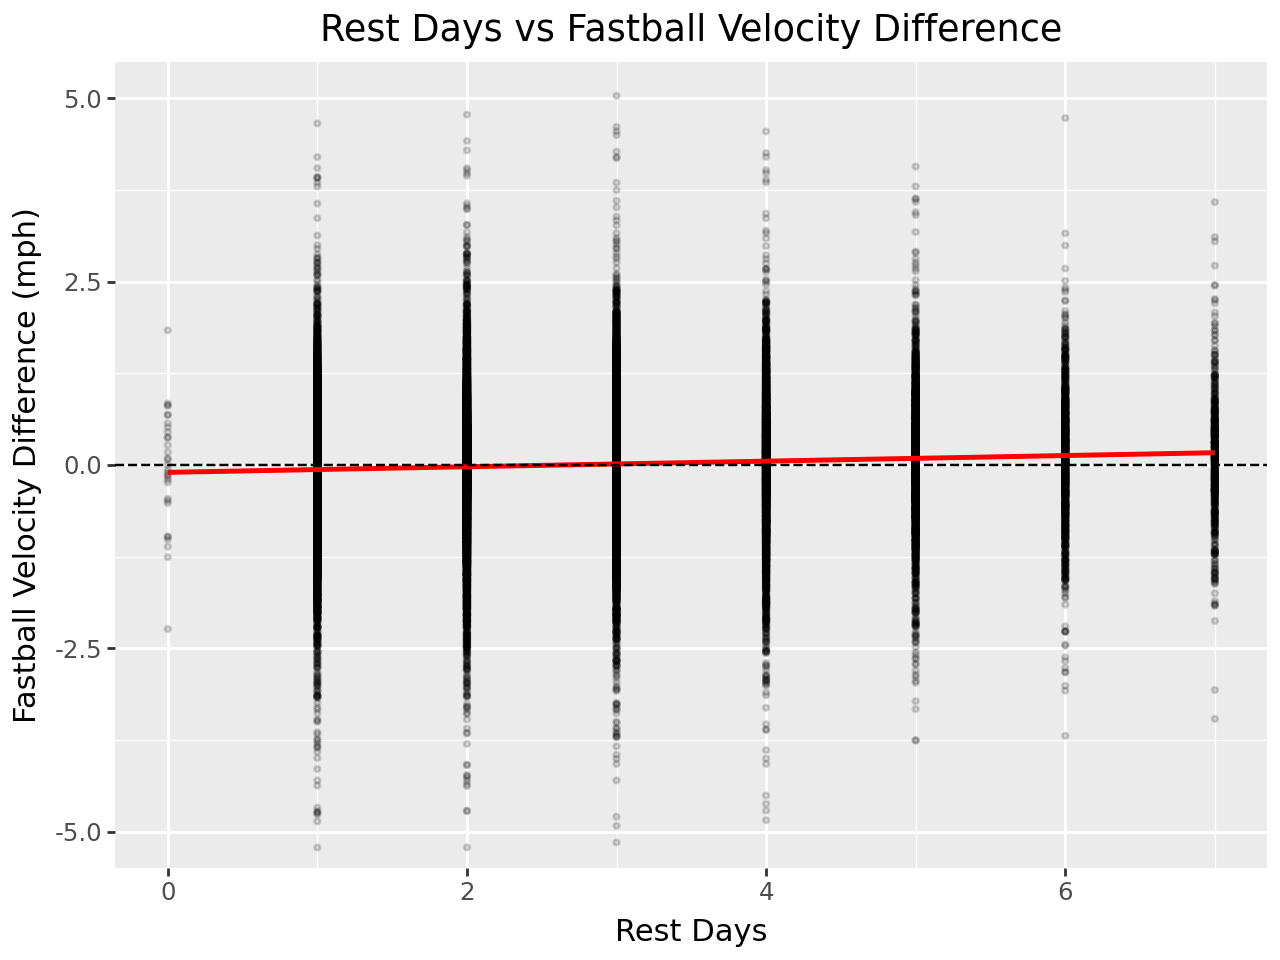

In [9]:
(
    ggplot(complete_outing_table, aes(x='rest_days', y='velo_deviation')) +
    geom_point(alpha=0.15, size=0.7) +
    geom_smooth(method='lm', se=True, color='red') +
    coord_cartesian(ylim=(-5, 5)) +
    geom_hline(yintercept=0, linetype='dashed') +
    labs(
        title='Rest Days vs Fastball Velocity Difference',
        x='Rest Days',
        y='Fastball Velocity Difference (mph)'
    )
)

C:\Users\kh6102sj\AppData\Local\Temp\ipykernel_9880\2789118570.py:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.


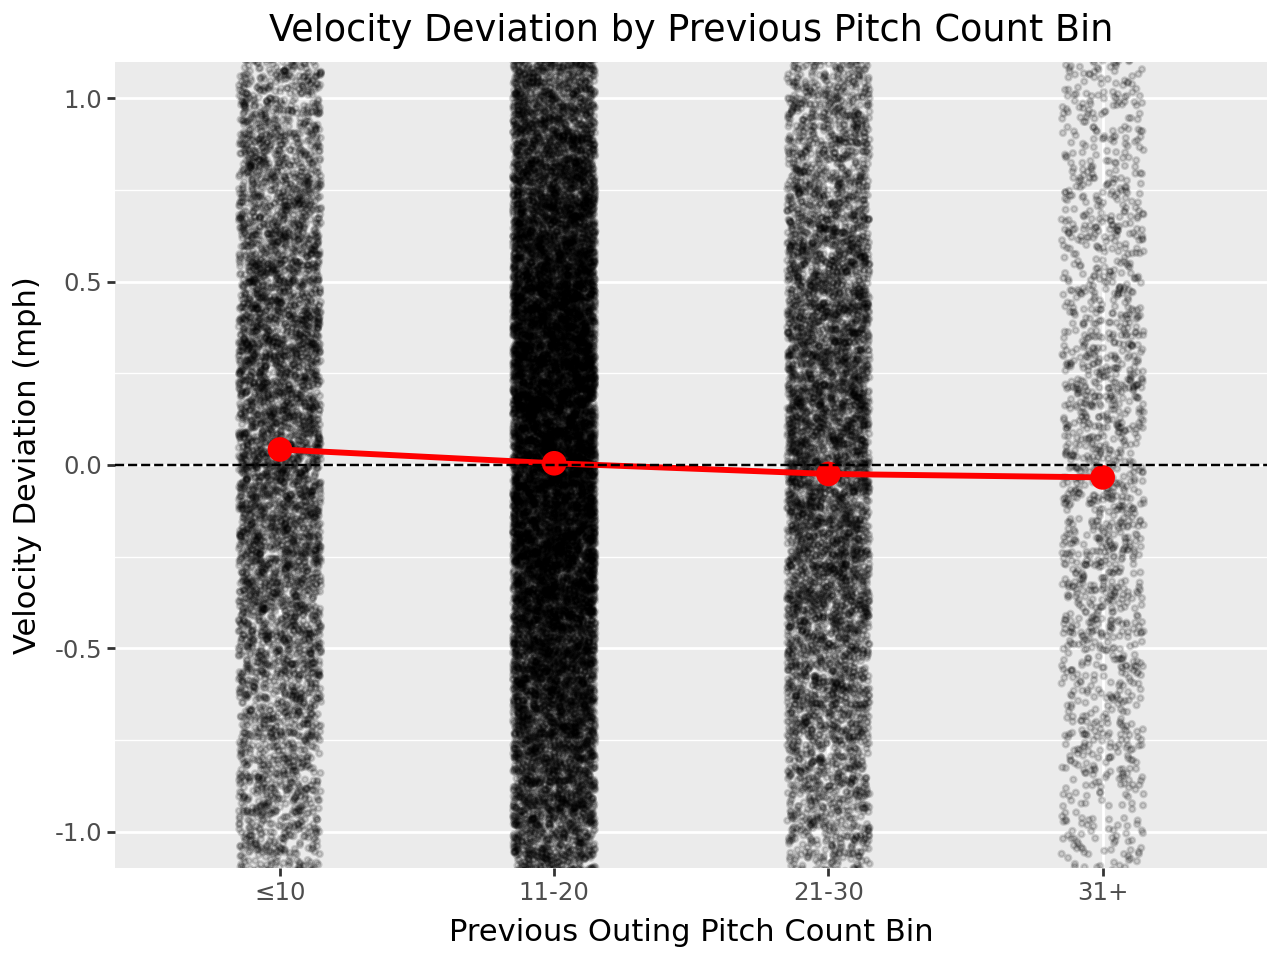

In [54]:

plot_df = (
    complete_outing_table
    .select(["prev_pitch_bin", "velo_deviation"])
    .drop_nulls(["prev_pitch_bin", "velo_deviation"])
    .to_pandas()
)

# Ensure correct order
order = ["≤10", "11-20", "21-30", "31+"]
plot_df["prev_pitch_bin"] = pd.Categorical(
    plot_df["prev_pitch_bin"],
    categories=order,
    ordered=True
)

# Compute means
mean_df = (
    plot_df
    .groupby("prev_pitch_bin", as_index=False)
    .mean(numeric_only=True)
)

(
    ggplot(plot_df, aes(x="prev_pitch_bin", y="velo_deviation")) +
    geom_jitter(alpha=0.15, width=0.15, size=0.7) +
    geom_line(
        data=mean_df,
        mapping=aes(x="prev_pitch_bin", y="velo_deviation", group=1),
        color="red",
        size=1.2
    ) +
    geom_point(
        data=mean_df,
        mapping=aes(x="prev_pitch_bin", y="velo_deviation"),
        color="red",
        size=4
    ) +
    geom_hline(yintercept=0, linetype="dashed") +
    coord_cartesian(ylim=(-1, 1)) +
    labs(
        title="Velocity Deviation by Previous Pitch Count Bin",
        x="Previous Outing Pitch Count Bin",
        y="Velocity Deviation (mph)"
    ) 
)

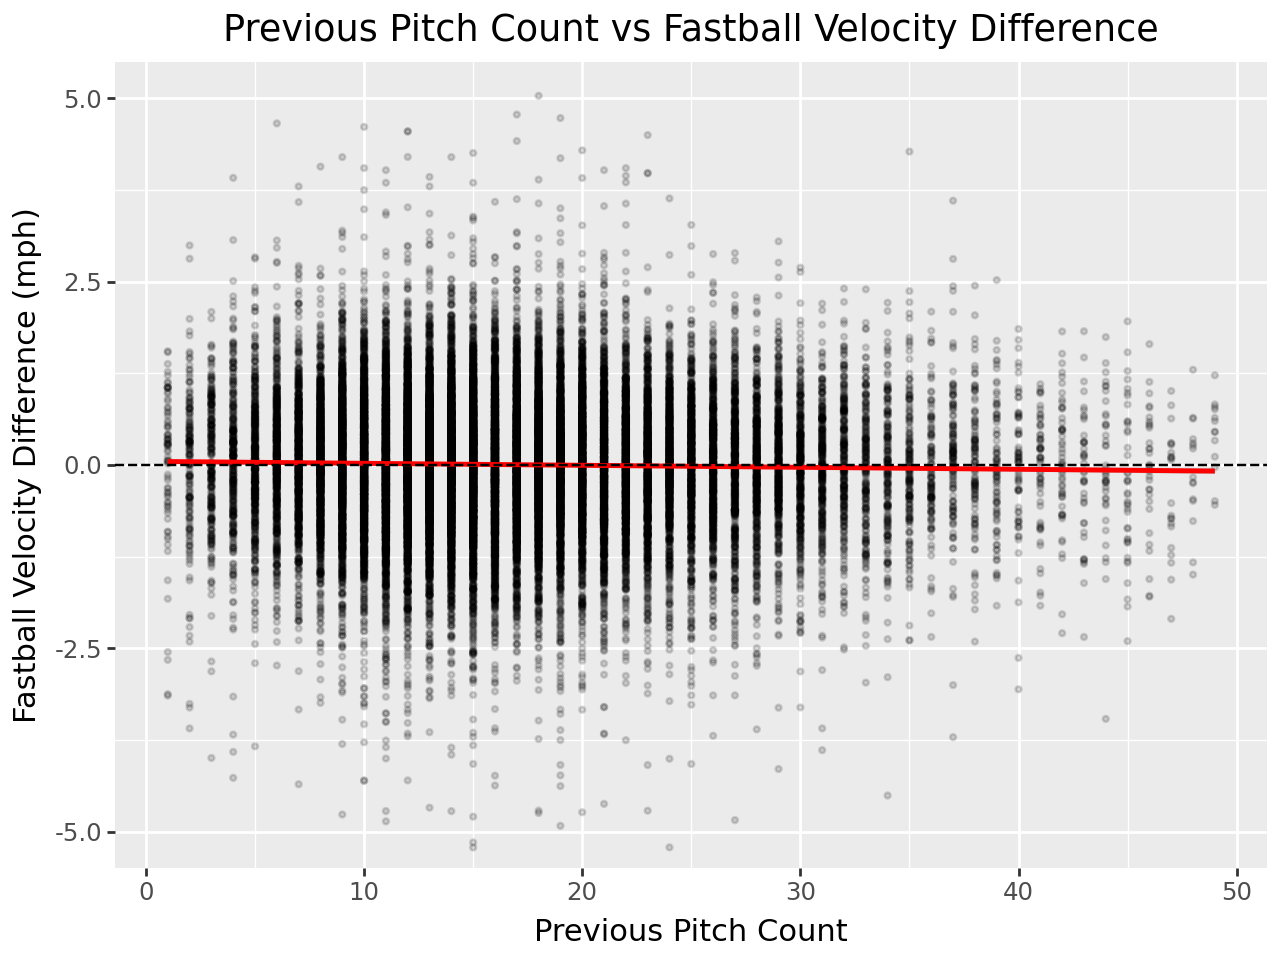

In [11]:
(
    ggplot(complete_outing_table, aes(x='prev_pitch_count', y='velo_deviation')) +
    geom_point(alpha=0.15, size=0.7) +
    geom_smooth(method='lm', se=True, color='red') +
    coord_cartesian(ylim=(-5, 5)) +
    geom_hline(yintercept=0, linetype='dashed') +
    labs(
        title='Previous Pitch Count vs Fastball Velocity Difference',
        x='Previous Pitch Count',
        y='Fastball Velocity Difference (mph)'
    ) 
)

c:\Users\kh6102sj\AppData\Local\anaconda3\envs\polars\Lib\site-packages\plotnine\layer.py:364: PlotnineWarning: geom_point : Removed 10432 rows containing missing values.


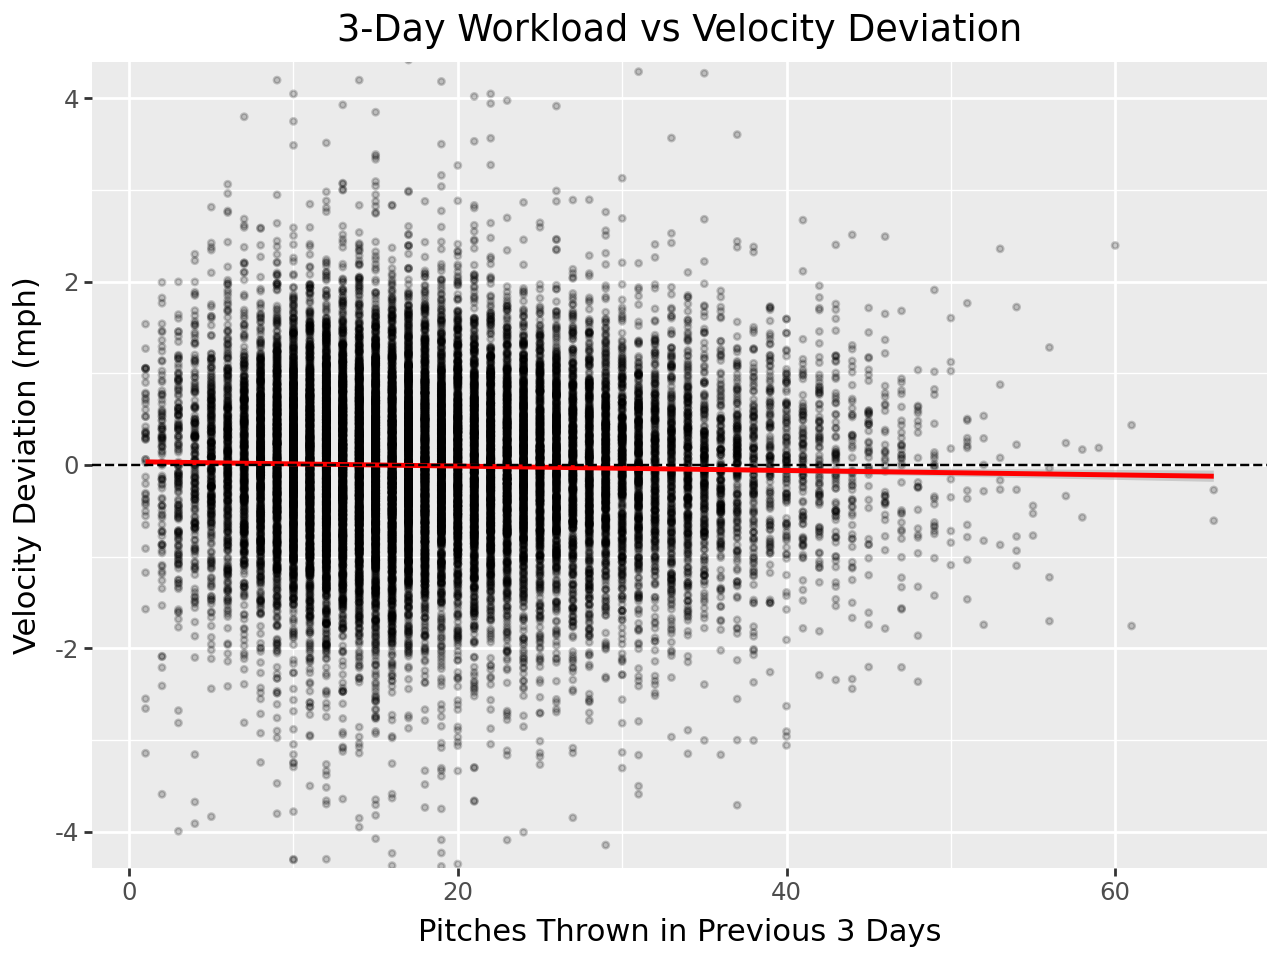

In [12]:
(
    ggplot(complete_outing_table,
           aes(x='pitches_last_3d', y='velo_deviation')) +
    geom_point(alpha=0.2, size=0.8) +
    geom_smooth(method='lm', se=True, color='red') +
    geom_hline(yintercept=0, linetype='dashed') +
    coord_cartesian(ylim=(-4, 4)) +
    labs(
        title='3-Day Workload vs Velocity Deviation',
        x='Pitches Thrown in Previous 3 Days',
        y='Velocity Deviation (mph)'
    )
)

c:\Users\kh6102sj\AppData\Local\anaconda3\envs\polars\Lib\site-packages\plotnine\layer.py:364: PlotnineWarning: geom_point : Removed 3563 rows containing missing values.


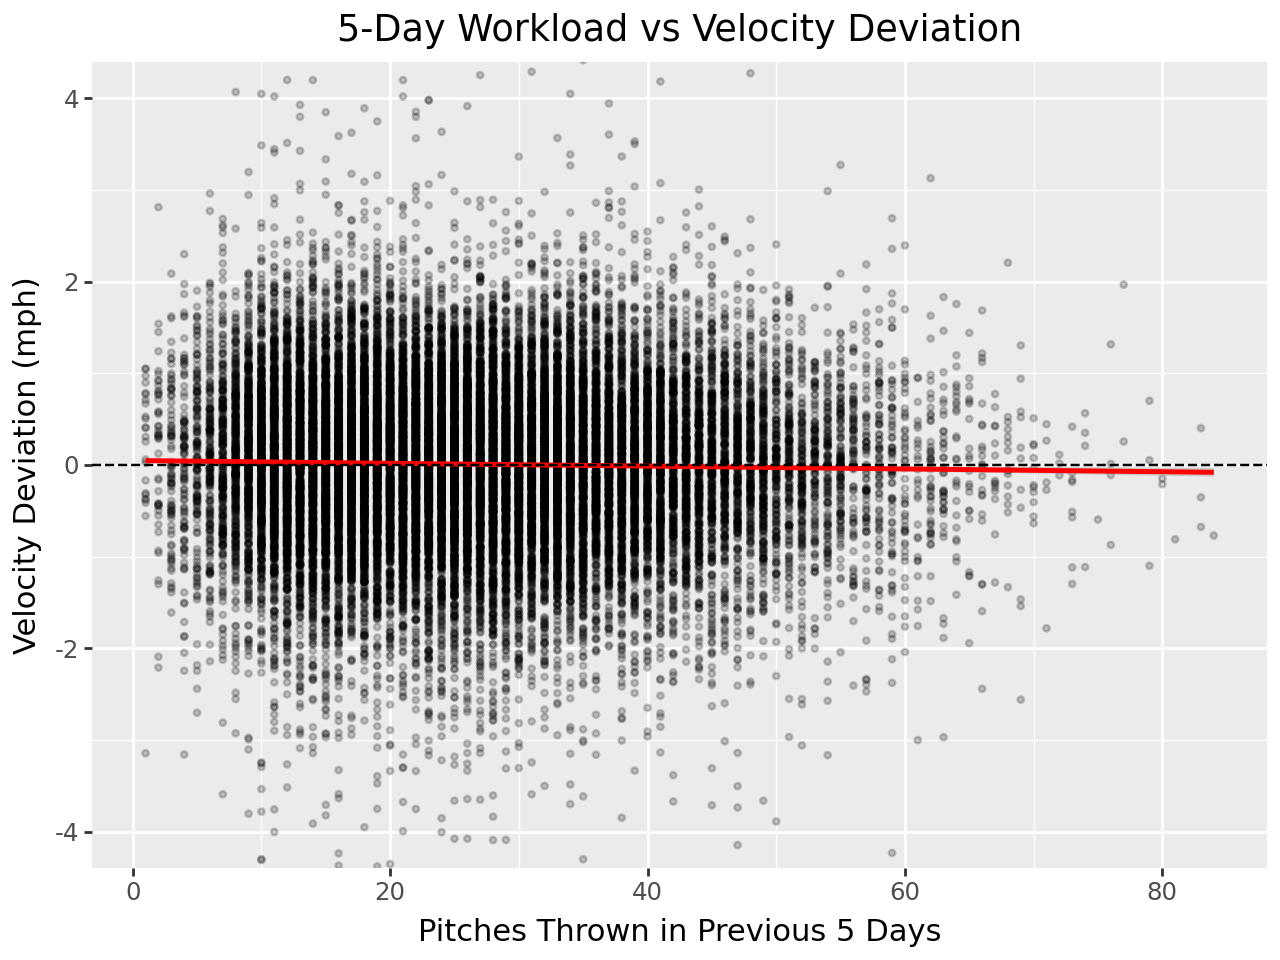

In [13]:
(
    ggplot(complete_outing_table,
           aes(x='pitches_last_5d', y='velo_deviation')) +
    geom_point(alpha=0.2, size=0.8) +
    geom_smooth(method='lm', se=True, color='red') +
    geom_hline(yintercept=0, linetype='dashed') +
    coord_cartesian(ylim=(-4, 4)) +
    labs(
        title='5-Day Workload vs Velocity Deviation',
        x='Pitches Thrown in Previous 5 Days',
        y='Velocity Deviation (mph)'
    )
)

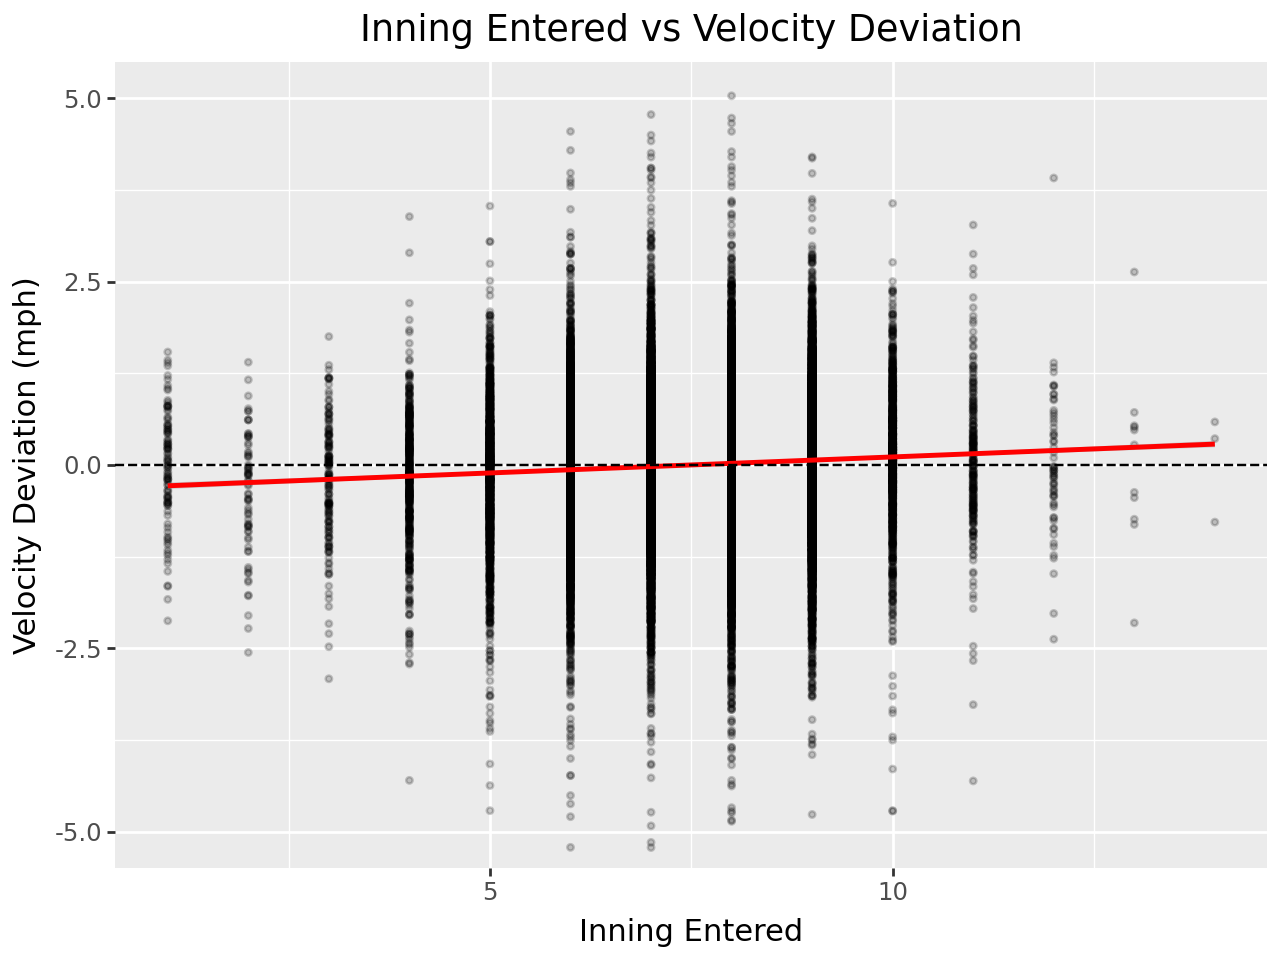

In [16]:
(
    ggplot(complete_outing_table,
           aes(x='inning_entered', y='velo_deviation')) +
    geom_point(alpha=0.2, size=0.8) +
    geom_smooth(method='lm', se=True, color = 'red') +
    geom_hline(yintercept=0, linetype='dashed') +
    coord_cartesian(ylim=(-5, 5)) +
    labs(
        title='Inning Entered vs Velocity Deviation',
        x='Inning Entered',
        y='Velocity Deviation (mph)'
    )
)

## Spin Rate

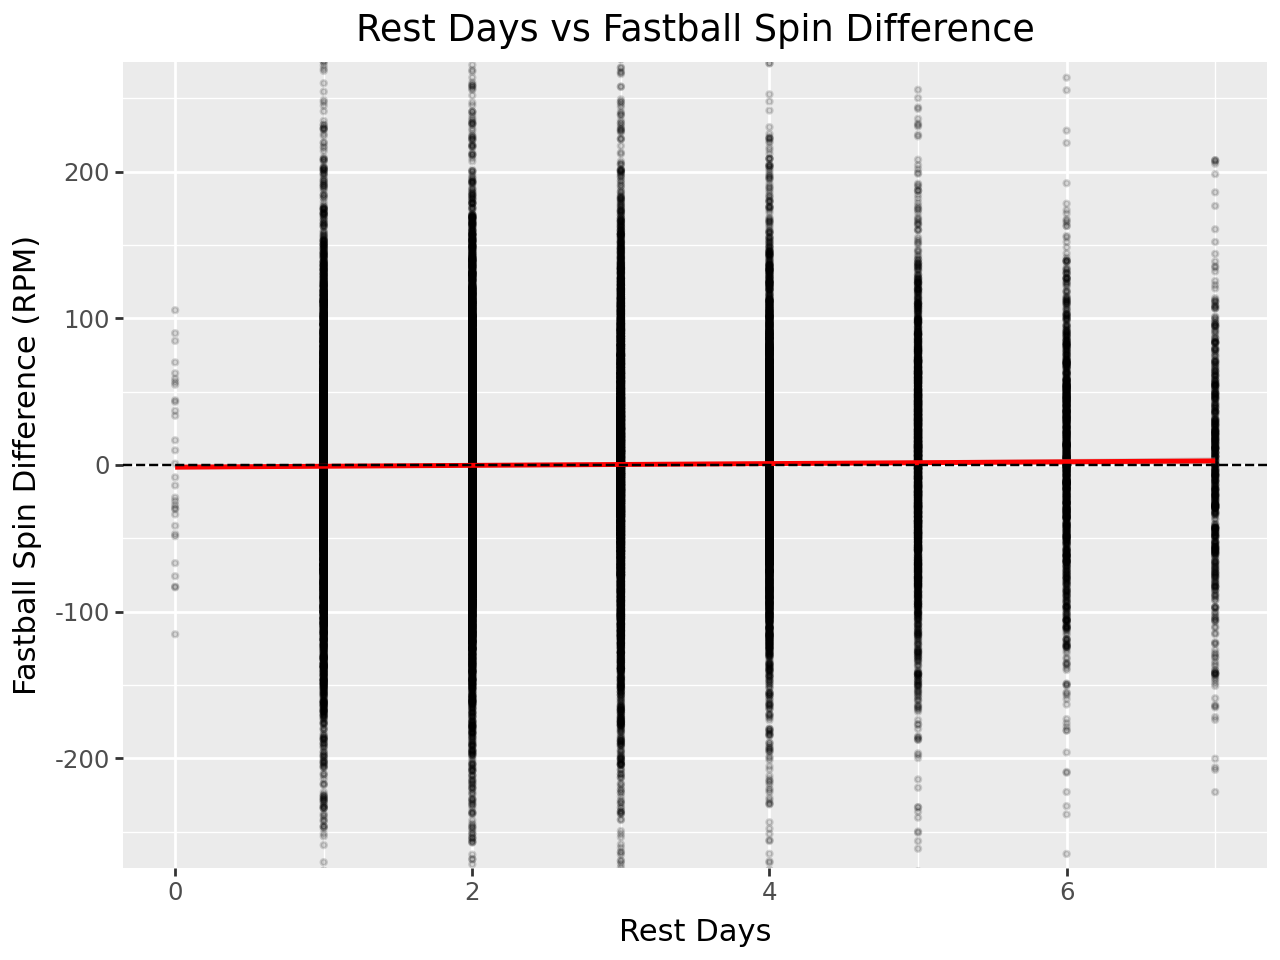

In [17]:
(
    ggplot(complete_outing_table, aes(x='rest_days', y='spin_deviation')) +
    geom_point(alpha=0.15, size=0.7) +
    geom_smooth(method='lm', se=True, color='red') +
    coord_cartesian(ylim=(-250, 250)) +
    geom_hline(yintercept=0, linetype='dashed') +
    labs(
        title='Rest Days vs Fastball Spin Difference',
        x='Rest Days',
        y='Fastball Spin Difference (RPM)'
    )
)

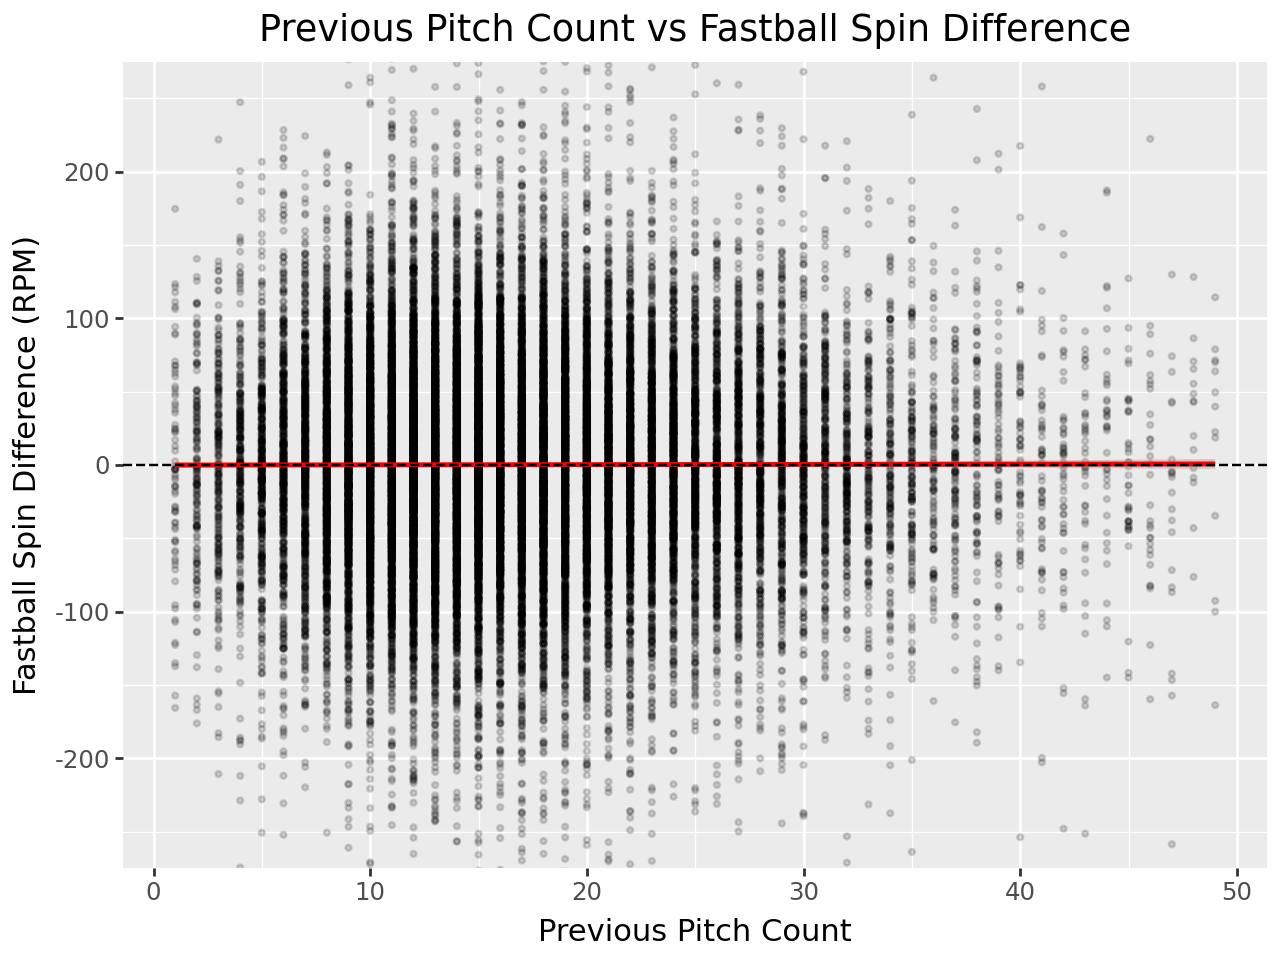

In [18]:
(
    ggplot(complete_outing_table, aes(x='prev_pitch_count', y='spin_deviation')) +
    geom_point(alpha=0.15, size=0.7) +
    geom_smooth(method='lm', se=True, color='red') +
    coord_cartesian(ylim=(-250, 250)) +
    geom_hline(yintercept=0, linetype='dashed') +
    labs(
        title='Previous Pitch Count vs Fastball Spin Difference',
        x='Previous Pitch Count',
        y='Fastball Spin Difference (RPM)'
    ) 
)

C:\Users\kh6102sj\AppData\Local\Temp\ipykernel_9880\4110423270.py:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.


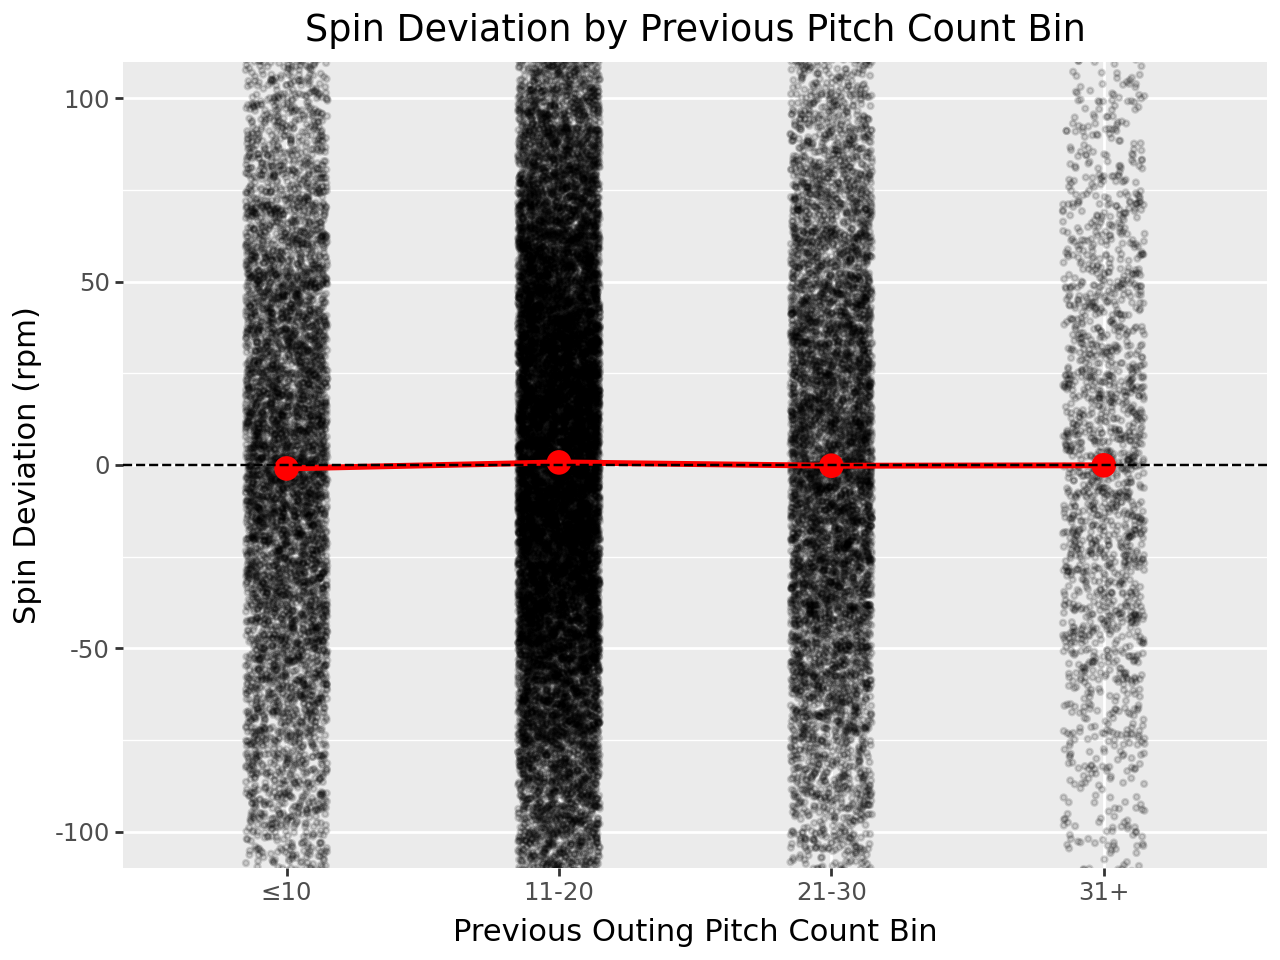

In [59]:

plot_df = (
    complete_outing_table
    .select(["prev_pitch_bin", "spin_deviation"])
    .drop_nulls(["prev_pitch_bin", "spin_deviation"])
    .to_pandas()
)

# Ensure correct order
order = ["≤10", "11-20", "21-30", "31+"]
plot_df["prev_pitch_bin"] = pd.Categorical(
    plot_df["prev_pitch_bin"],
    categories=order,
    ordered=True
)

# Compute means
mean_df = (
    plot_df
    .groupby("prev_pitch_bin", as_index=False)
    .mean(numeric_only=True)
)

(
    ggplot(plot_df, aes(x="prev_pitch_bin", y="spin_deviation")) +
    geom_jitter(alpha=0.15, width=0.15, size=0.7) +
    geom_line(
        data=mean_df,
        mapping=aes(x="prev_pitch_bin", y="spin_deviation", group=1),
        color="red",
        size=1.2
    ) +
    geom_point(
        data=mean_df,
        mapping=aes(x="prev_pitch_bin", y="spin_deviation"),
        color="red",
        size=4
    ) +
    geom_hline(yintercept=0, linetype="dashed") +
    coord_cartesian(ylim=(-100, 100)) +
    labs(
        title="Spin Deviation by Previous Pitch Count Bin",
        x="Previous Outing Pitch Count Bin",
        y="Spin Deviation (rpm)"
    ) 
)

In [56]:
(
    ggplot(plot_df, aes(x="prev_pitch_bin", y="spin_deviation")) +
    geom_jitter(alpha=0.15, width=0.15, size=0.7) +
    geom_line(
        data=mean_df,
        mapping=aes(x="prev_pitch_bin", y="spin_deviation", group=1),
        color="red",
        size=1.2
    ) +
    geom_point(
        data=mean_df,
        mapping=aes(x="prev_pitch_bin", y="spin_deviation"),
        color="red",
        size=4
    ) +
    geom_hline(yintercept=0, linetype="dashed") +
    coord_cartesian(ylim=(-1, 1)) +
    labs(
        title="Velocity Deviation by Previous Pitch Count Bin",
        x="Previous Outing Pitch Count Bin",
        y="Velocity Deviation (mph)"
    ) 
)

PlotnineError: "Could not evaluate the 'y' mapping: 'spin_deviation' (original error: name 'spin_deviation' is not defined)"

c:\Users\kh6102sj\AppData\Local\anaconda3\envs\polars\Lib\site-packages\plotnine\layer.py:364: PlotnineWarning: geom_point : Removed 10342 rows containing missing values.


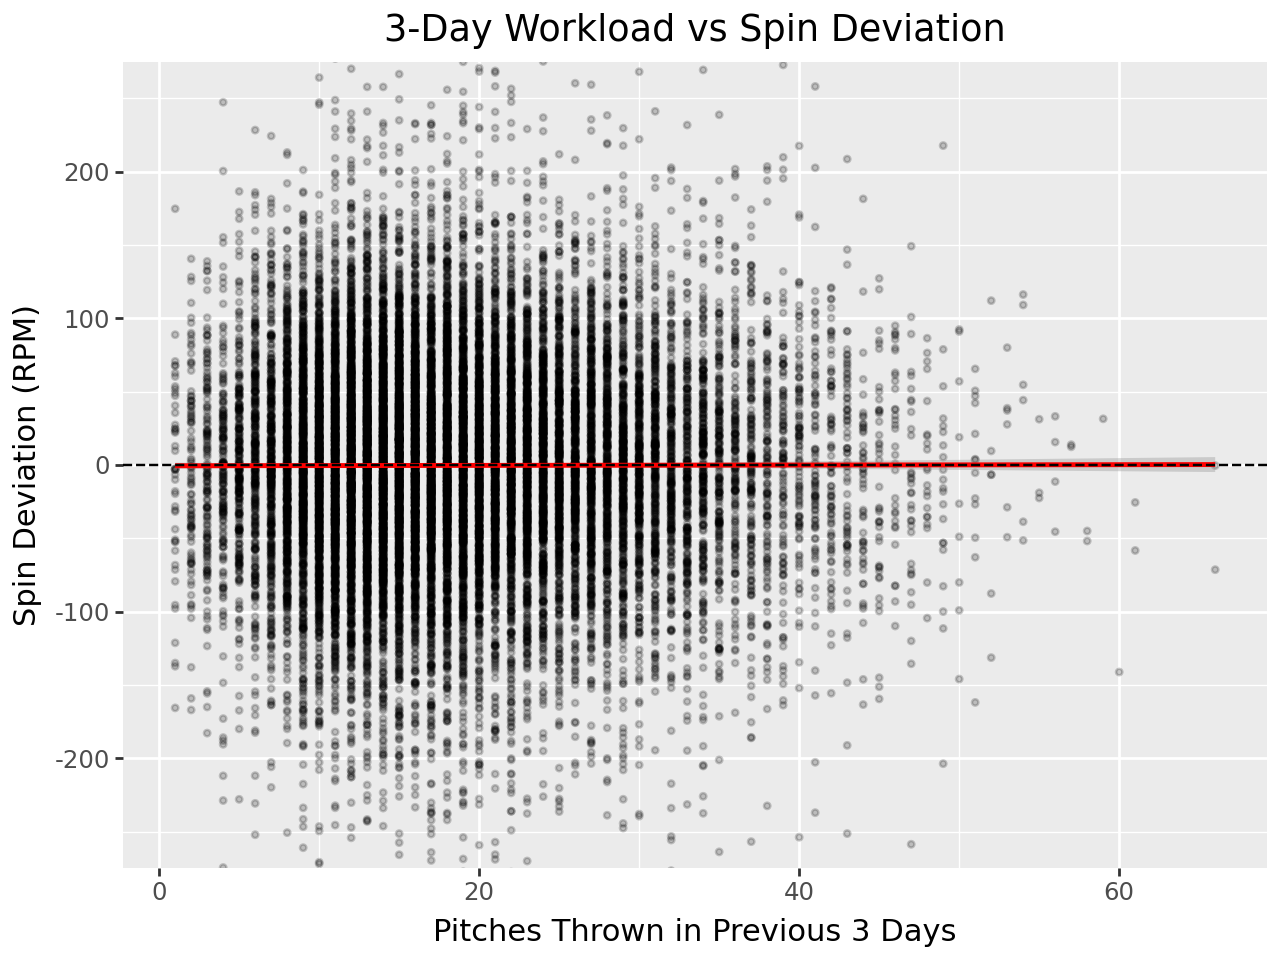

In [19]:
(
    ggplot(complete_outing_table,
           aes(x='pitches_last_3d', y='spin_deviation')) +
    geom_point(alpha=0.2, size=0.8) +
    geom_smooth(method='lm', se=True, color='red') +
    geom_hline(yintercept=0, linetype='dashed') +
    coord_cartesian(ylim=(-250, 250)) +
    labs(
        title='3-Day Workload vs Spin Deviation',
        x='Pitches Thrown in Previous 3 Days',
        y='Spin Deviation (RPM)'
    )
)

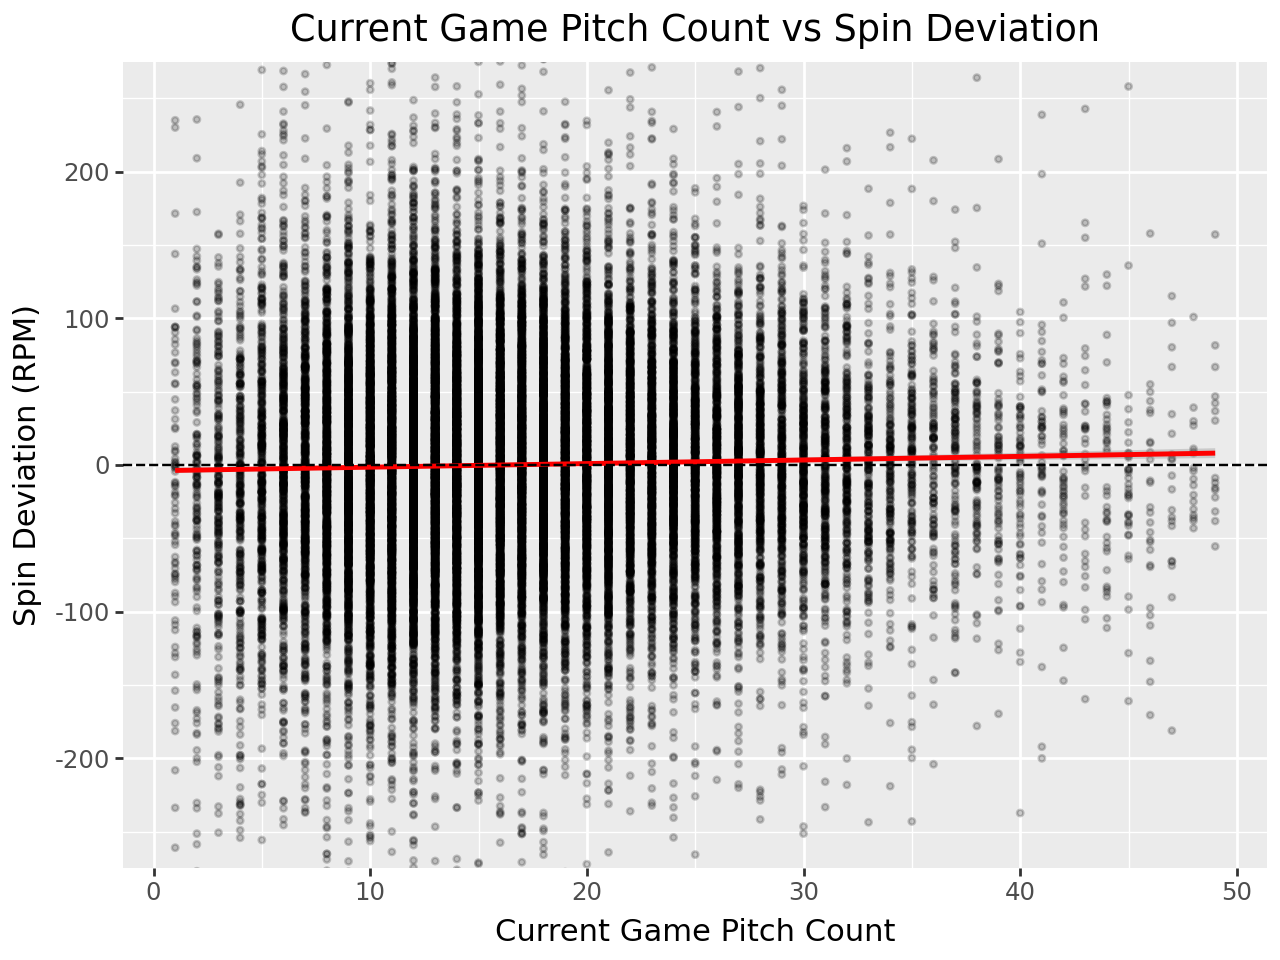

In [20]:
(
    ggplot(complete_outing_table,
           aes(x='pitch_count', y='spin_deviation')) +
    geom_point(alpha=0.2, size=0.8) +
    geom_smooth(method='lm', se=True, color='red') +
    geom_hline(yintercept=0, linetype='dashed') +
    coord_cartesian(ylim=(-250, 250)) +
    labs(
        title='Current Game Pitch Count vs Spin Deviation',
        x='Current Game Pitch Count',
        y='Spin Deviation (RPM)'
    )
)

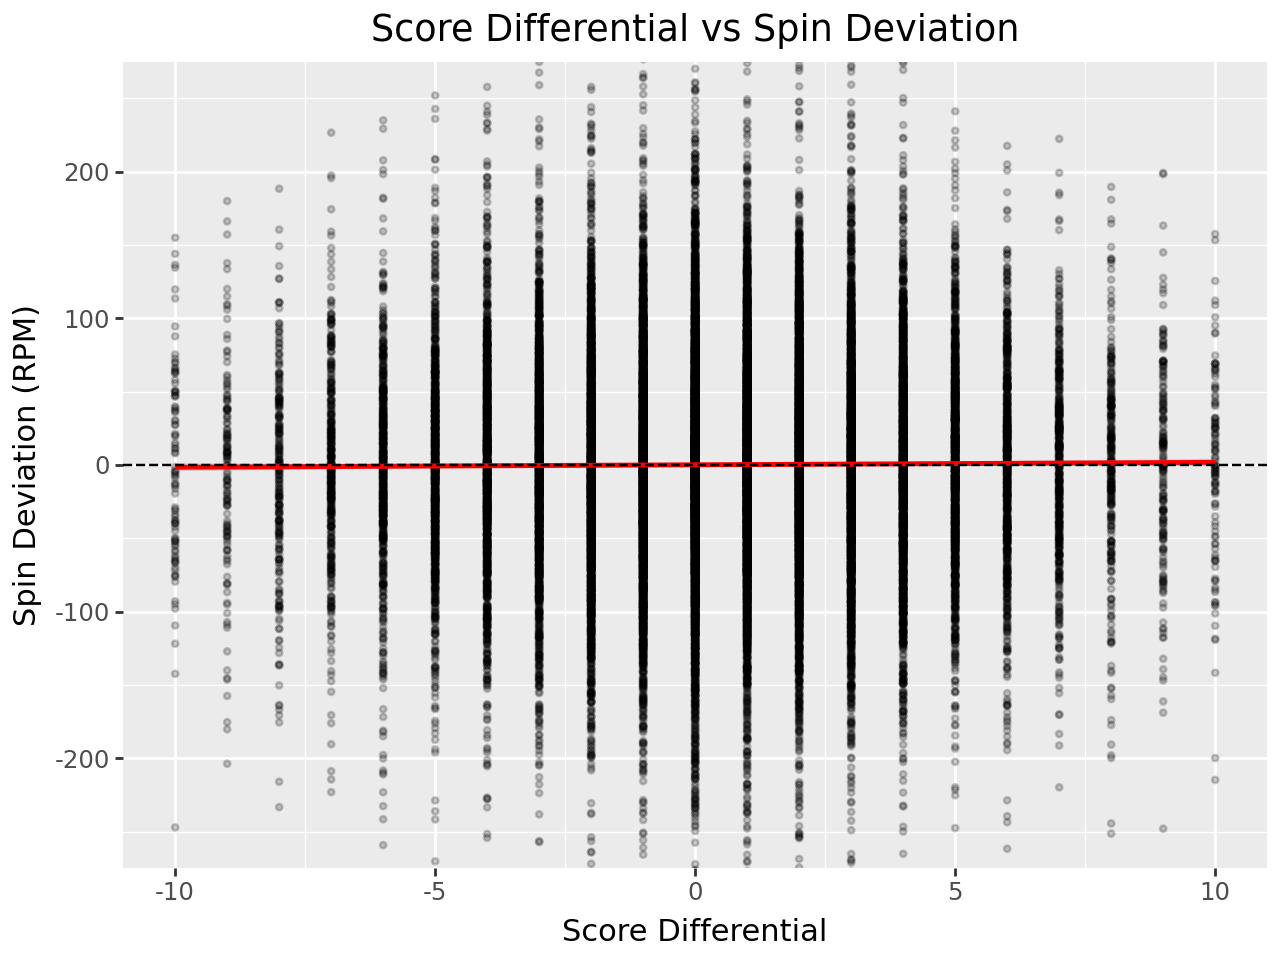

In [21]:
(
    ggplot(complete_outing_table,
           aes(x='score_diff', y='spin_deviation')) +
    geom_point(alpha=0.2, size=0.8) +
    geom_smooth(method='lm', se=True, color='red') +
    geom_hline(yintercept=0, linetype='dashed') +
    coord_cartesian(ylim=(-250, 250)) +
    labs(
        title='Score Differential vs Spin Deviation',
        x='Score Differential',
        y='Spin Deviation (RPM)'
    )
)

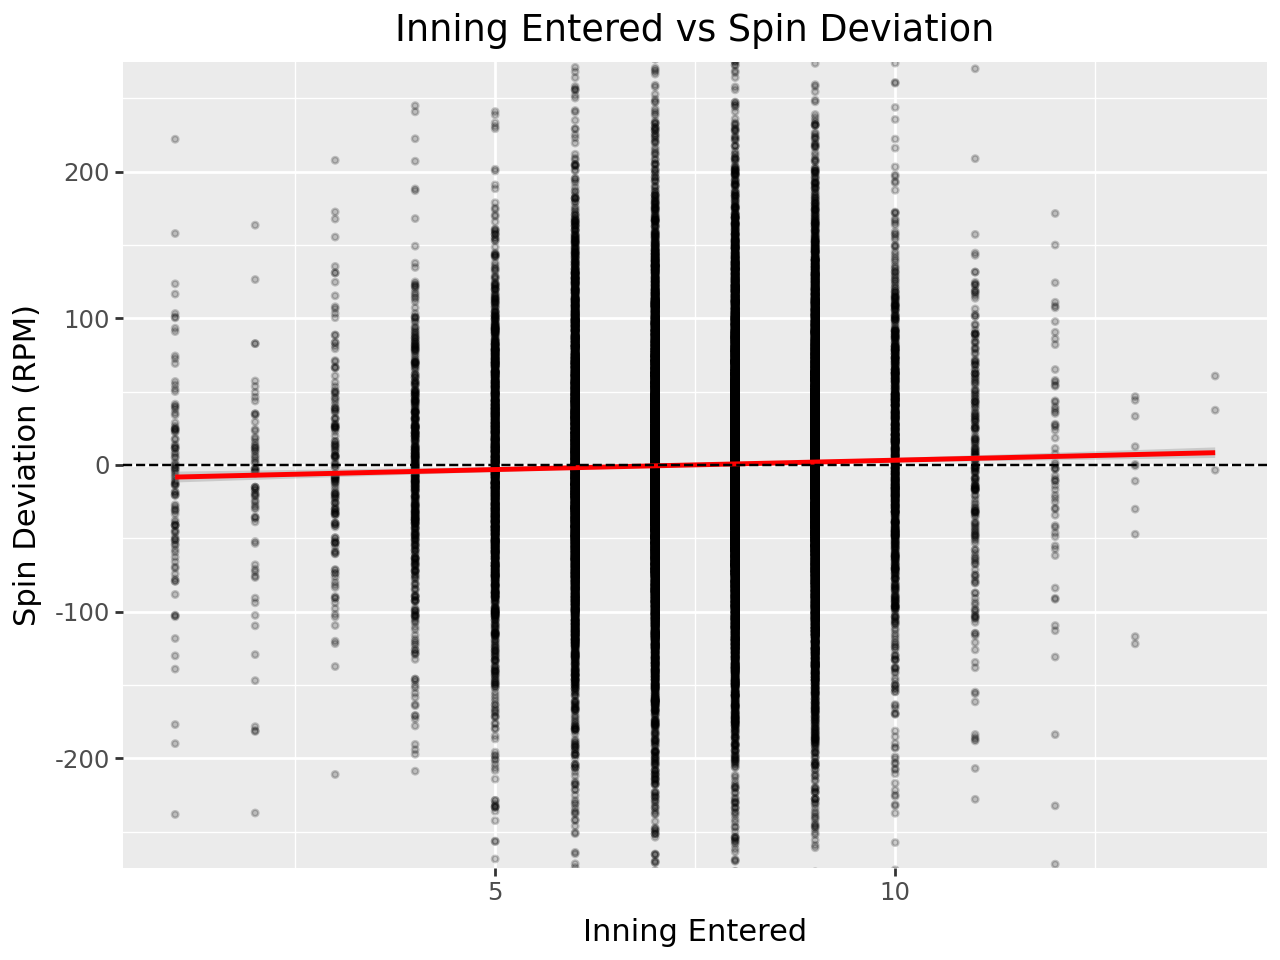

In [22]:
(
    ggplot(complete_outing_table,
           aes(x='inning_entered', y='spin_deviation')) +
    geom_point(alpha=0.2, size=0.8) +
    geom_smooth(method='lm', se=True, color='red') +
    geom_hline(yintercept=0, linetype='dashed') +
    coord_cartesian(ylim=(-250, 250)) +
    labs(
        title='Inning Entered vs Spin Deviation',
        x='Inning Entered',
        y='Spin Deviation (RPM)'
    )
)

## Horizontal Movement

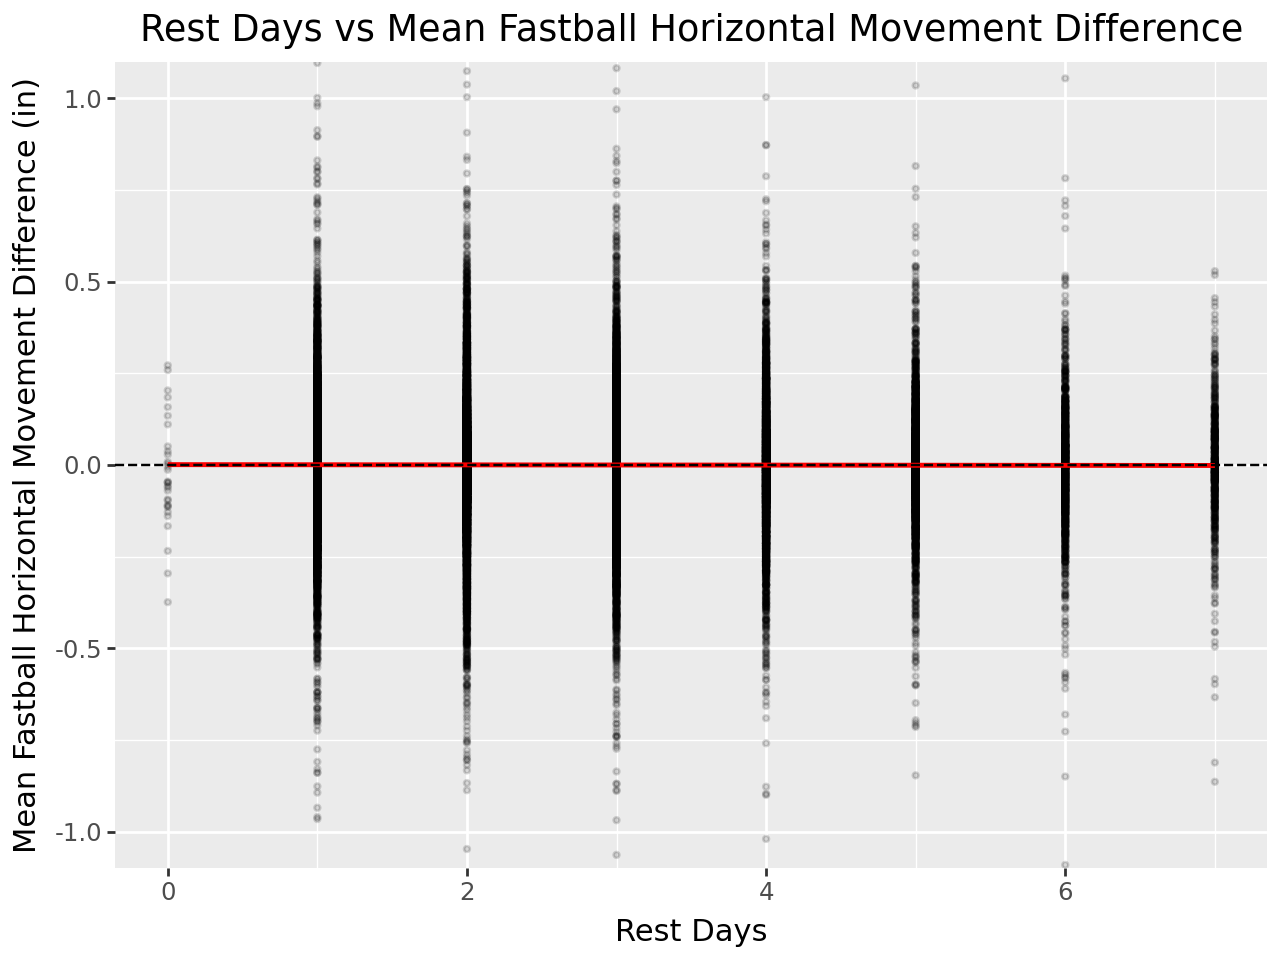

In [23]:
(
    ggplot(complete_outing_table, aes(x='rest_days', y='h_movement_deviation')) +
    geom_point(alpha=0.15, size=0.7) +
    geom_smooth(method='lm', se=True, color='red') +
    coord_cartesian(ylim=(-1, 1)) +
    geom_hline(yintercept=0, linetype='dashed') +
    labs(
        title='Rest Days vs Mean Fastball Horizontal Movement Difference',
        x='Rest Days',
        y='Mean Fastball Horizontal Movement Difference (in)'
    )
)

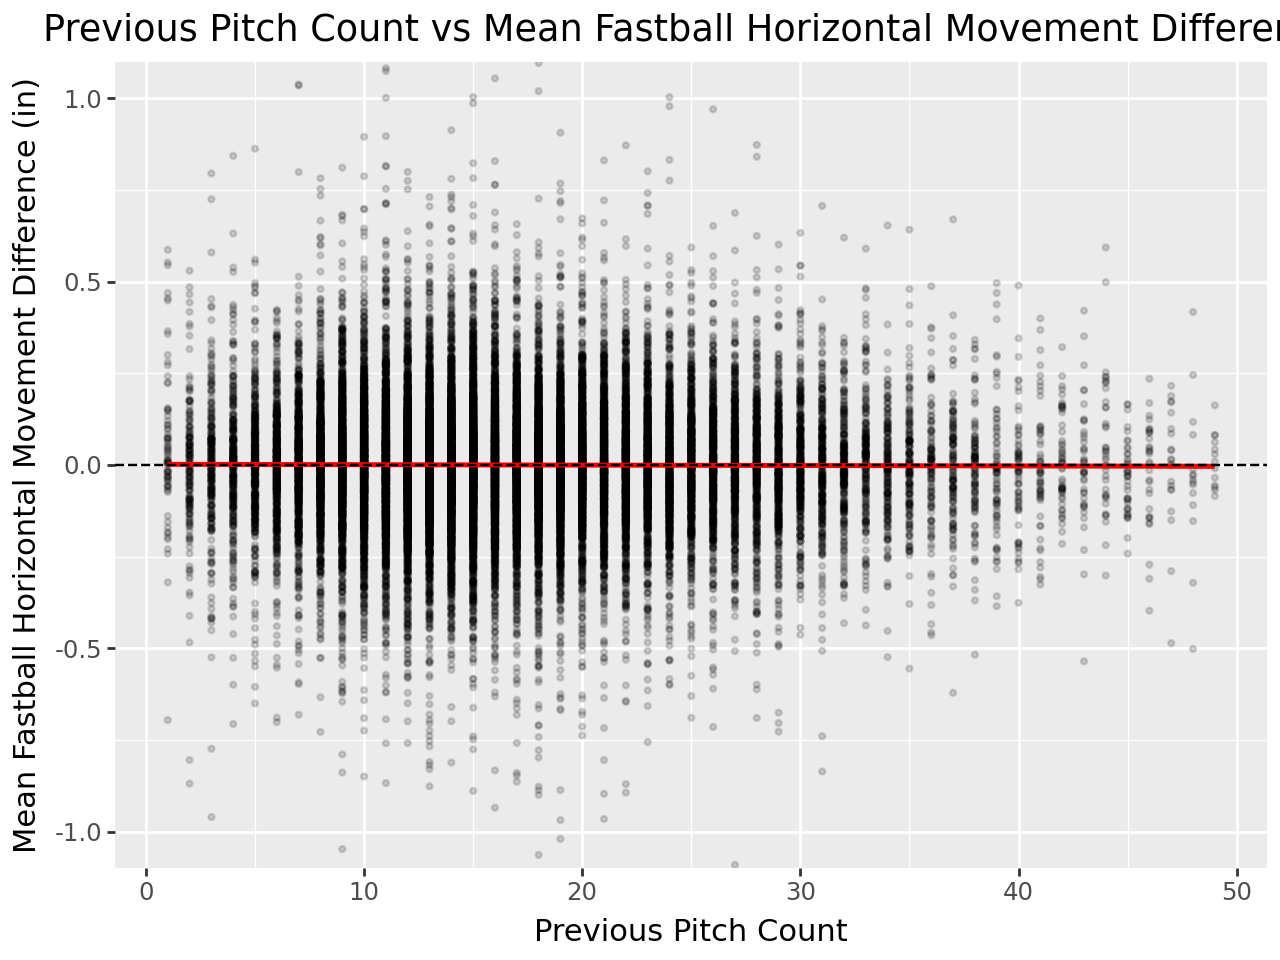

In [24]:
(
    ggplot(complete_outing_table, aes(x='prev_pitch_count', y='h_movement_deviation')) +
    geom_point(alpha=0.15, size=0.7) +
    geom_smooth(method='lm', se=True, color='red') +
    coord_cartesian(ylim=(-1, 1)) +
    geom_hline(yintercept=0, linetype='dashed') +
    labs(
        title='Previous Pitch Count vs Mean Fastball Horizontal Movement Difference',
        x='Previous Pitch Count',
        y='Mean Fastball Horizontal Movement Difference (in)'
    ) 
)

c:\Users\kh6102sj\AppData\Local\anaconda3\envs\polars\Lib\site-packages\plotnine\layer.py:364: PlotnineWarning: geom_point : Removed 10342 rows containing missing values.


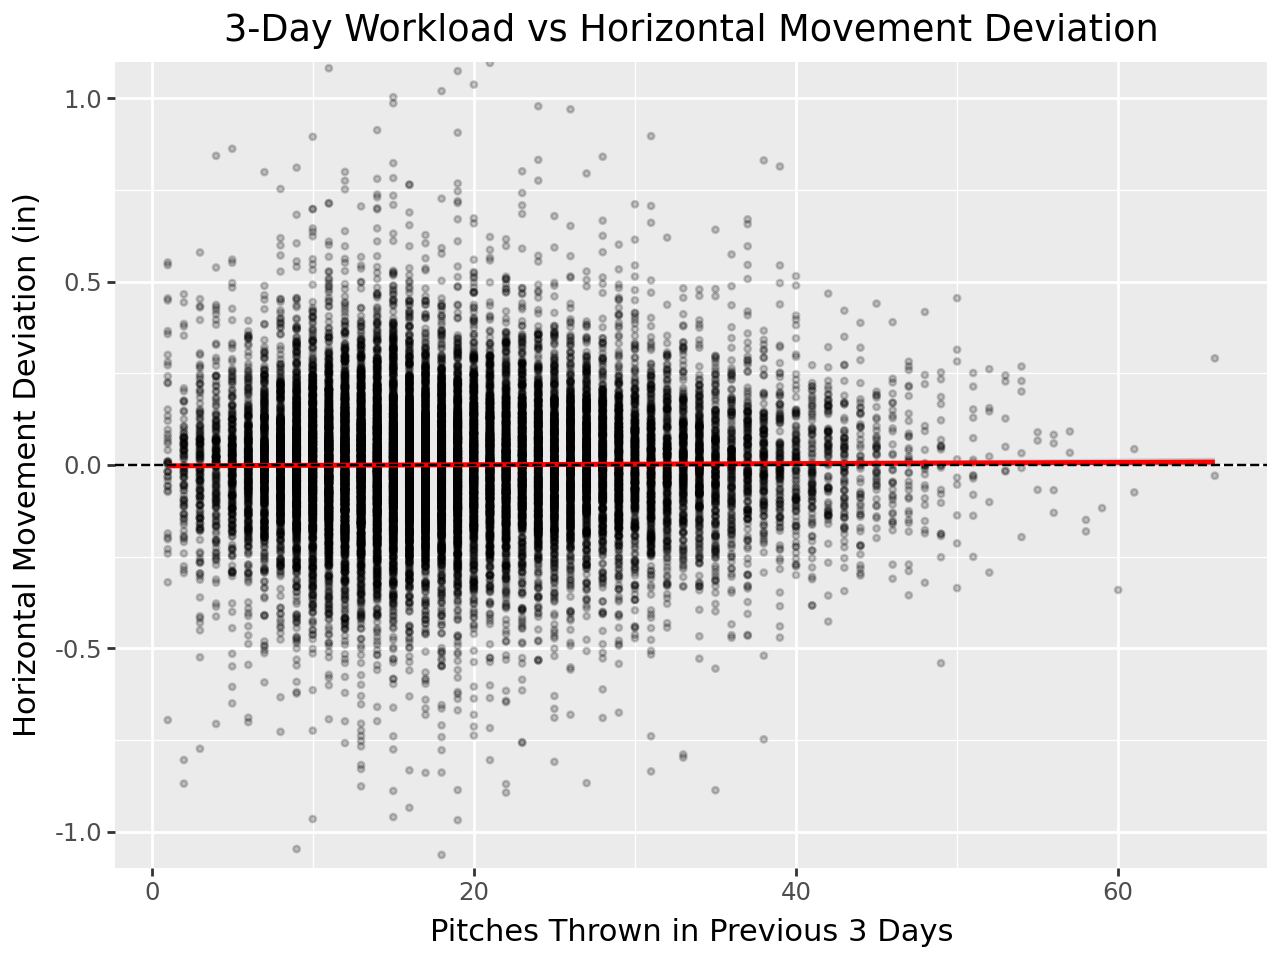

In [25]:
(
    ggplot(complete_outing_table,
           aes(x='pitches_last_3d', y='h_movement_deviation')) +
    geom_point(alpha=0.2, size=0.8) +
    geom_smooth(method='lm', se=True, color='red') +
    geom_hline(yintercept=0, linetype='dashed') +
    coord_cartesian(ylim=(-1, 1)) +
    labs(
        title='3-Day Workload vs Horizontal Movement Deviation',
        x='Pitches Thrown in Previous 3 Days',
        y='Horizontal Movement Deviation (in)'
    )
)

## Vertical Movement

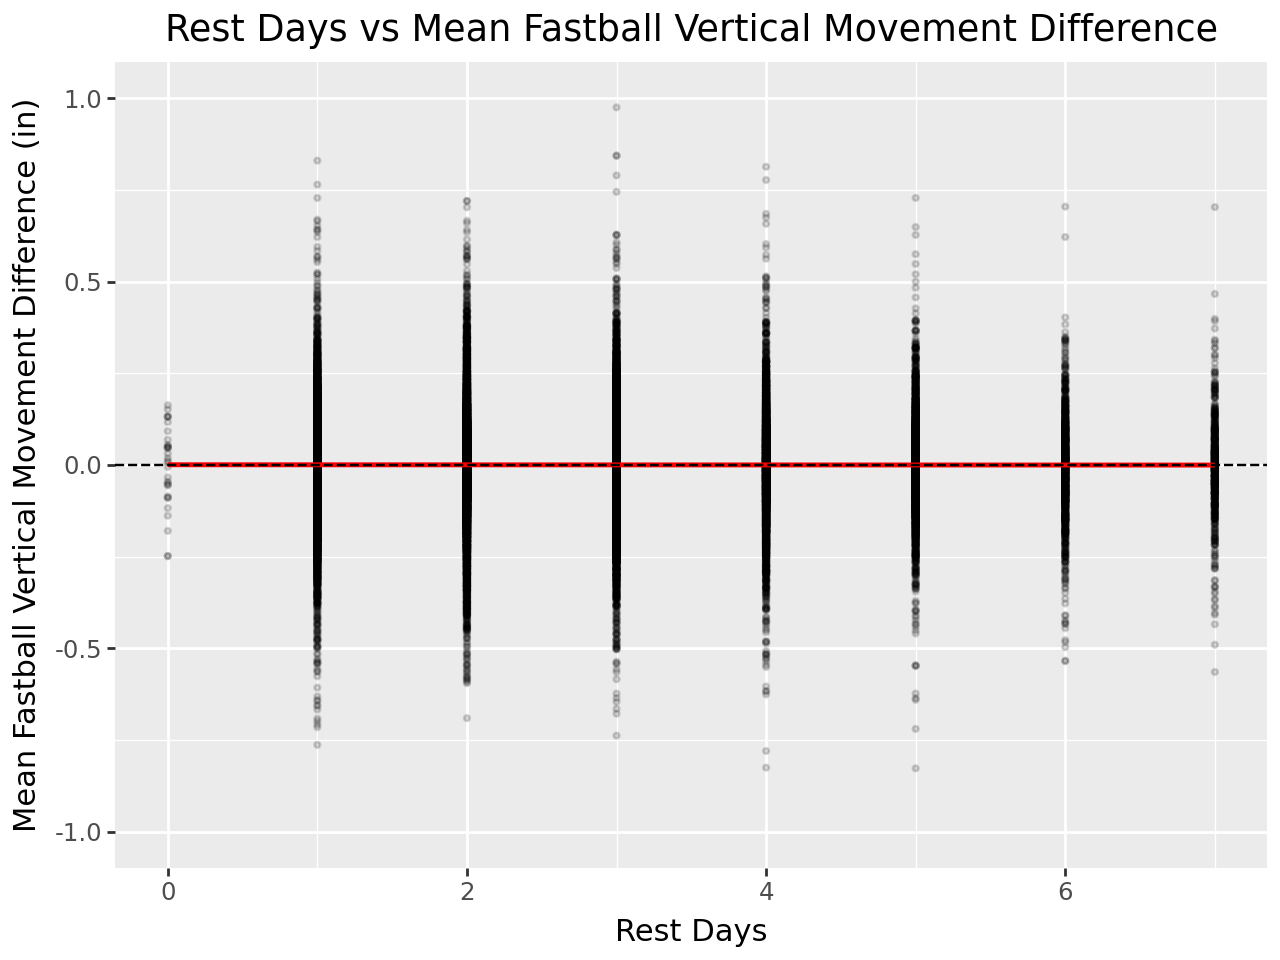

In [26]:
(
    ggplot(complete_outing_table, aes(x='rest_days', y='v_movement_deviation')) +
    geom_point(alpha=0.15, size=0.7) +
    geom_smooth(method='lm', se=True, color='red') +
    coord_cartesian(ylim=(-1, 1)) +
    geom_hline(yintercept=0, linetype='dashed') +
    labs(
        title='Rest Days vs Mean Fastball Vertical Movement Difference',
        x='Rest Days',
        y='Mean Fastball Vertical Movement Difference (in)'
    )
)

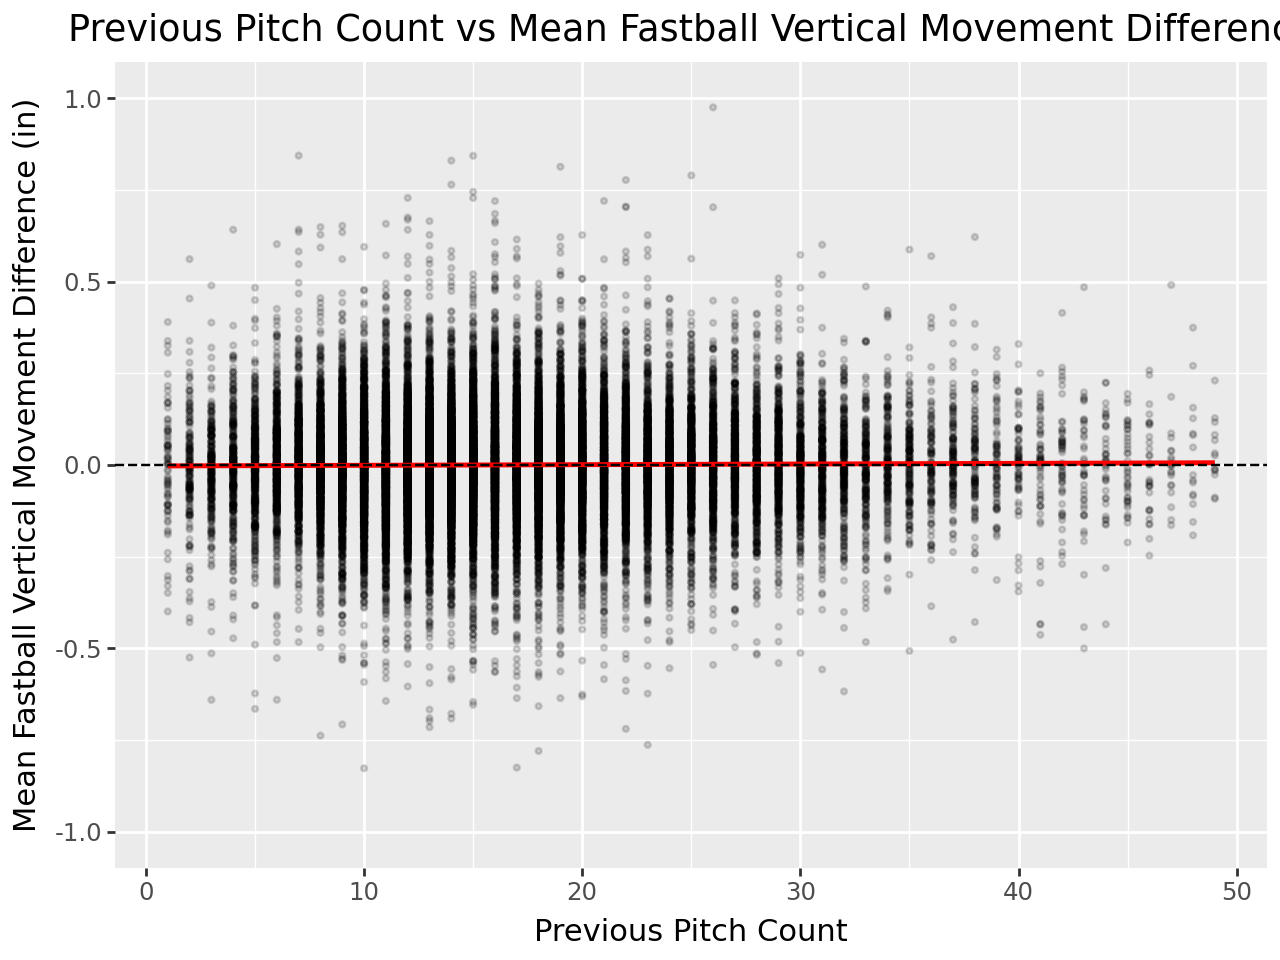

In [27]:
(
    ggplot(complete_outing_table, aes(x='prev_pitch_count', y='v_movement_deviation')) +
    geom_point(alpha=0.15, size=0.7) +
    geom_smooth(method='lm', se=True, color='red') +
    coord_cartesian(ylim=(-1, 1)) +
    geom_hline(yintercept=0, linetype='dashed') +
    labs(
        title='Previous Pitch Count vs Mean Fastball Vertical Movement Difference',
        x='Previous Pitch Count',
        y='Mean Fastball Vertical Movement Difference (in)'
    ) 
)

c:\Users\kh6102sj\AppData\Local\anaconda3\envs\polars\Lib\site-packages\plotnine\layer.py:364: PlotnineWarning: geom_point : Removed 10342 rows containing missing values.


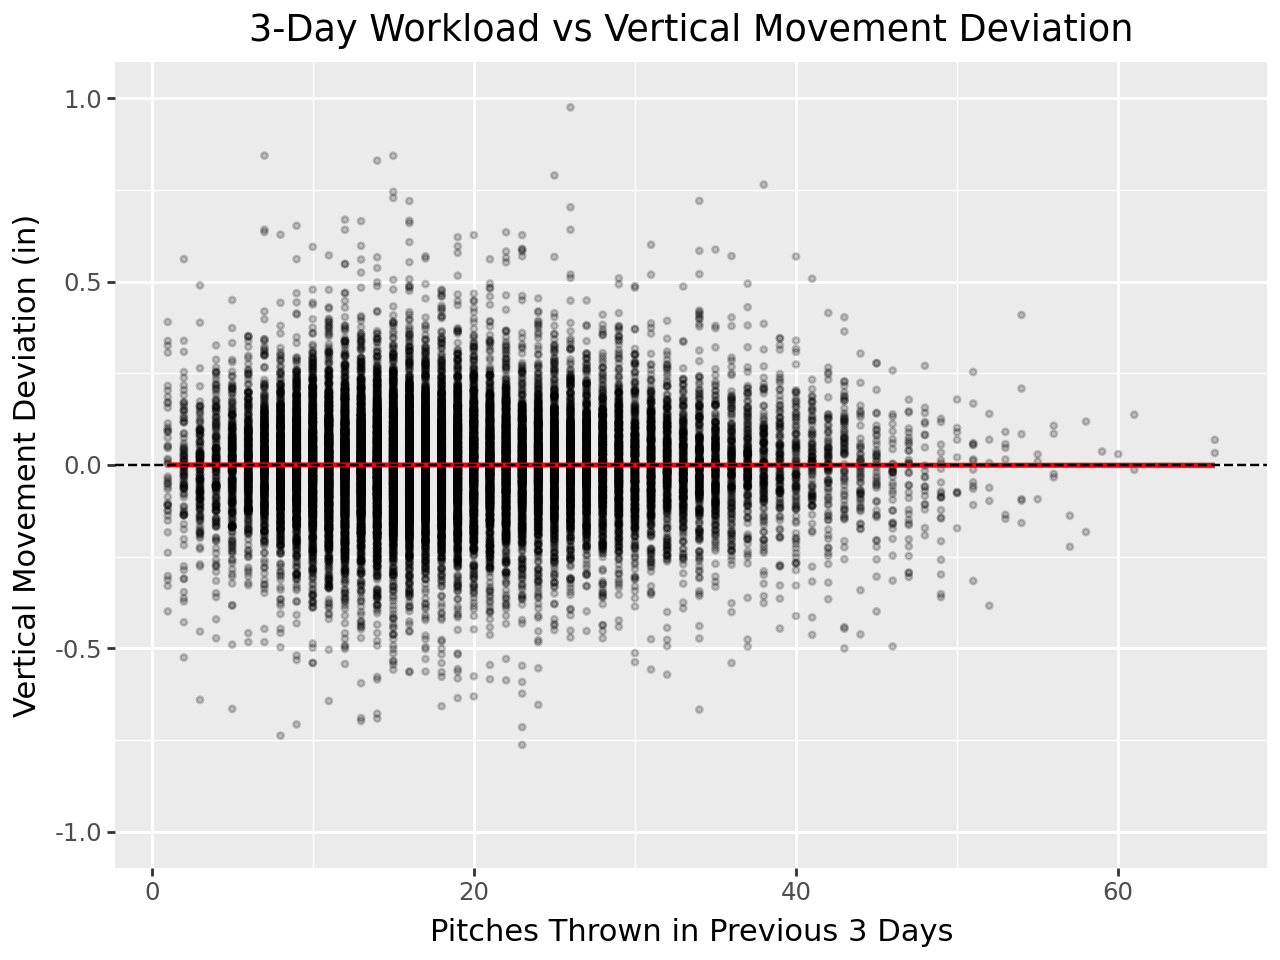

In [28]:
(
    ggplot(complete_outing_table,
           aes(x='pitches_last_3d', y='v_movement_deviation')) +
    geom_point(alpha=0.2, size=0.8) +
    geom_smooth(method='lm', se=True, color='red') +
    geom_hline(yintercept=0, linetype='dashed') +
    coord_cartesian(ylim=(-1, 1)) +
    labs(
        title='3-Day Workload vs Vertical Movement Deviation',
        x='Pitches Thrown in Previous 3 Days',
        y='Vertical Movement Deviation (in)'
    )
)

## Models

### Bivariate

In [29]:
def quick_ols(x, y):
    d = complete_outing_table.select([x, y]).drop_nulls([x, y]).to_pandas()

    X = sm.add_constant(d[x])
    model = sm.OLS(d[y], X).fit()

    b = model.params[x]
    lo, hi = model.conf_int().loc[x].tolist()
    p = model.pvalues[x]
    n = int(model.nobs)
    r2 = model.rsquared

    print(f"{y} ~ {x} | slope={b:.4f}  95%CI=({lo:.4f},{hi:.4f})  p={p:.3g}  N={n}  R²={r2:.4f}")

    return model

In [30]:
xs = [
    "rest_days",
    "prev_pitch_count",
    "pitches_last_3d",
    "pitches_last_5d",
    "pitch_count",
    "score_diff",
    "inning_entered"
]

for x in xs:
    quick_ols(x, "velo_deviation")

velo_deviation ~ rest_days | slope=0.0381  95%CI=(0.0315,0.0447)  p=2.44e-29  N=34733  R²=0.0036
velo_deviation ~ prev_pitch_count | slope=-0.0026  95%CI=(-0.0039,-0.0014)  p=3.09e-05  N=34733  R²=0.0005
velo_deviation ~ pitches_last_3d | slope=-0.0024  95%CI=(-0.0036,-0.0011)  p=0.000293  N=24391  R²=0.0005
velo_deviation ~ pitches_last_5d | slope=-0.0015  95%CI=(-0.0023,-0.0007)  p=0.000237  N=31205  R²=0.0004
velo_deviation ~ pitch_count | slope=0.0009  95%CI=(-0.0004,0.0021)  p=0.174  N=34733  R²=0.0001
velo_deviation ~ score_diff | slope=0.0128  95%CI=(0.0098,0.0157)  p=1.83e-17  N=34733  R²=0.0021
velo_deviation ~ inning_entered | slope=0.0437  95%CI=(0.0371,0.0504)  p=9.21e-38  N=34733  R²=0.0047


While rest days and contextual variables showed statistically significant associations with fastball velocity deviation, the magnitude of these effects was minimal (all slopes < 0.05 mph per unit change, R² < 0.005). These findings suggest that short-term workload and rest variation explain virtually none of the variation in relief pitcher fastball velocity.

In [31]:
quick_ols("rest_days", "spin_deviation")
quick_ols("rest_days", "h_movement_deviation")
quick_ols("rest_days", "v_movement_deviation")

spin_deviation ~ rest_days | slope=0.6068  95%CI=(0.0604,1.1533)  p=0.0295  N=34733  R²=0.0001
h_movement_deviation ~ rest_days | slope=-0.0003  95%CI=(-0.0016,0.0009)  p=0.612  N=34733  R²=0.0000
v_movement_deviation ~ rest_days | slope=-0.0001  95%CI=(-0.0012,0.0009)  p=0.816  N=34733  R²=0.0000


In [32]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

def sklearn_linear(x, y):
    d = complete_outing_table.select([x, y]).drop_nulls([x, y]).to_pandas()

    X = d[[x]].values
    Y = d[y].values

    model = LinearRegression()
    model.fit(X, Y)

    predictions = model.predict(X)

    slope = model.coef_[0]
    intercept = model.intercept_
    r2 = r2_score(Y, predictions)
    n = len(Y)

    print(f"{y} ~ {x} | slope={slope:.4f}  intercept={intercept:.4f}  N={n}  R²={r2:.4f}")

    return model


In [33]:
xs = [
    "rest_days",
    "prev_pitch_count",
    "pitches_last_3d",
    "pitch_count",
    "score_diff",
    "inning_entered"
]

for x in xs:
    sklearn_linear(x, "velo_deviation")

velo_deviation ~ rest_days | slope=0.0381  intercept=-0.1010  N=34733  R²=0.0036
velo_deviation ~ prev_pitch_count | slope=-0.0026  intercept=0.0478  N=34733  R²=0.0005
velo_deviation ~ pitches_last_3d | slope=-0.0024  intercept=0.0351  N=24391  R²=0.0005
velo_deviation ~ pitch_count | slope=0.0009  intercept=-0.0112  N=34733  R²=0.0001
velo_deviation ~ score_diff | slope=0.0128  intercept=-0.0018  N=34733  R²=0.0021
velo_deviation ~ inning_entered | slope=0.0437  intercept=-0.3285  N=34733  R²=0.0047


In [34]:
ys = [
    "spin_deviation",
    "h_movement_deviation",
    "v_movement_deviation"
]

for y in ys:
    sklearn_linear("rest_days", y)

spin_deviation ~ rest_days | slope=0.6068  intercept=-1.5290  N=34733  R²=0.0001
h_movement_deviation ~ rest_days | slope=-0.0003  intercept=0.0007  N=34733  R²=0.0000
v_movement_deviation ~ rest_days | slope=-0.0001  intercept=0.0004  N=34733  R²=0.0000


### Multivariate

In [35]:
# Multivariable linear regression (scikit-learn) using your outing-level variables
# Goal: quantify the combined effect of rest + workload + context on velo_deviation

import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# Features (X) and target (y) — using your existing columns
features = ["rest_days", "prev_pitch_count", "pitches_last_3d", "inning_entered", "score_diff"]
target = "velo_deviation"

# Select + drop missing rows (pitches_last_3d reduces N vs other features)
d = complete_outing_table.select(features + [target]).drop_nulls(features + [target]).to_pandas()

X = d[features].values
y = d[target].values

model = LinearRegression()
model.fit(X, y)

pred = model.predict(X)
r2 = r2_score(y, pred)
n = len(y)

# Output a clean coefficient table
coef_table = pd.DataFrame({
    "feature": features,
    "slope": model.coef_
}).sort_values("slope", ascending=False)

print(f"Multivariable model: {target} ~ " + " + ".join(features))
print(f"N={n}  R²={r2:.4f}  intercept={model.intercept_:.4f}")
print("\nCoefficients (slopes):")
display(coef_table.reset_index(drop=True))

Multivariable model: velo_deviation ~ rest_days + prev_pitch_count + pitches_last_3d + inning_entered + score_diff
N=24391  R²=0.0117  intercept=-0.4570

Coefficients (slopes):


,feature,slope
0,rest_days,0.088627
1,inning_entered,0.042598
2,score_diff,0.011358
3,pitches_last_3d,0.001284
4,prev_pitch_count,-0.005484


When accounting simultaneously for rest, recent workload, and game context, fastball velocity deviation remains minimally explained (R² = 0.0117). However, rest days show a modest positive association (~0.09 mph per additional day), suggesting small but measurable recovery effects when controlling for other usage variables.

In [36]:
import polars as pl
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

features = ["rest_days", "prev_pitch_count", "pitches_last_3d", "inning_entered", "score_diff"]

# Create absolute deviation target (stability)
complete_outing_table = complete_outing_table.with_columns(
    pl.col("velo_deviation").abs().alias("abs_velo_deviation")
)

# Fit multivariable model for absolute deviation
target = "abs_velo_deviation"
d = complete_outing_table.select(features + [target]).drop_nulls(features + [target]).to_pandas()

X = d[features].values
y = d[target].values

model_abs = LinearRegression()
model_abs.fit(X, y)

pred = model_abs.predict(X)
r2 = r2_score(y, pred)

coef_table = pd.DataFrame({"feature": features, "slope": model_abs.coef_}).sort_values("slope", ascending=False)

print(f"Multivariable model: {target} ~ " + " + ".join(features))
print(f"N={len(y)}  R²={r2:.4f}  intercept={model_abs.intercept_:.4f}")
display(coef_table.reset_index(drop=True))

Multivariable model: abs_velo_deviation ~ rest_days + prev_pitch_count + pitches_last_3d + inning_entered + score_diff
N=24391  R²=0.0004  intercept=0.7197


,feature,slope
0,prev_pitch_count,0.000505
1,inning_entered,-0.000827
2,pitches_last_3d,-0.001196
3,score_diff,-0.001968
4,rest_days,-0.009815


In [37]:
import polars as pl
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score

features = ["rest_days", "prev_pitch_count", "pitches_last_3d", "inning_entered", "score_diff"]
target = "velo_deviation"

d = complete_outing_table.select(features + [target]).drop_nulls(features + [target]).to_pandas()

X = d[features].values
y = d[target].values

scaler = StandardScaler()
Xz = scaler.fit_transform(X)

model_z = LinearRegression()
model_z.fit(Xz, y)

pred = model_z.predict(Xz)
r2 = r2_score(y, pred)

std_coef_table = pd.DataFrame({
    "feature": features,
    "standardized_coef": model_z.coef_
}).assign(abs_coef=lambda t: t["standardized_coef"].abs()) \
  .sort_values("abs_coef", ascending=False) \
  .drop(columns="abs_coef")

print(f"Standardized multivariable model: {target} ~ " + " + ".join(features))
print(f"N={len(y)}  R²={r2:.4f}")
display(std_coef_table.reset_index(drop=True))

Standardized multivariable model: velo_deviation ~ rest_days + prev_pitch_count + pitches_last_3d + inning_entered + score_diff
N=24391  R²=0.0117


,feature,standardized_coef
0,rest_days,0.067911
1,inning_entered,0.060211
2,prev_pitch_count,-0.039199
3,score_diff,0.034235
4,pitches_last_3d,0.011282


## Strike Percentage

In [38]:
relievers["pitch_result"].unique().to_list()

['automatic_strike',
 'swinging_strike_blocked',
 'foul_tip',
 'foul_bunt',
 'hit_into_play',
 'automatic_ball',
 'foul',
 'swinging_strike',
 'pitchout',
 'blocked_ball',
 'hit_by_pitch',
 'missed_bunt',
 'called_strike',
 'bunt_foul_tip',
 'ball']

In [39]:
strike_results = [
    'foul_tip', 'called_strike', 'automatic_strike', 'foul',
    'swinging_strike_blocked', 'bunt_foul_tip', 'swinging_strike',
    'missed_bunt', 'foul_bunt', 'hit_into_play'
]
ball_results = [
    'ball', 'pitchout', 'automatic_ball', 'blocked_ball', 'hit_by_pitch'
]

In [40]:
(relievers := relievers.with_columns(
    pl.when(pl.col("pitch_result").is_in(strike_results)).then(pl.lit("s"))
    .when(pl.col("pitch_result").is_in(ball_results)).then(pl.lit("b"))
    .otherwise(pl.lit("x"))
    .alias("strike/ball")
)).head(2)

pitcher_id,date,game_id,velocity,spin_rate,pitch_type_abbr,pitch_type,pitch_result,ab_result,pitch_call,strike_zone,ball_count,strike_count,outs,inning,top_bottom,home_team,away_team,ab_number,pitch_num,batted_ball_type,runner_1b,runner_2b,runner_3b,away_score,home_score,defense_score,offense_score,game_type,batter_side,pitcher_hand,pitcher_days_since_prev_game,pitcher_days_until_next_game,year,pitcher_name,strike/ball
i64,datetime[ns],i64,f64,i64,str,str,str,str,str,i64,i64,i64,i64,i64,str,str,str,i64,i64,str,i64,i64,i64,i64,i64,i64,i64,str,str,str,i64,i64,i32,str,str
433589,2021-04-01 00:00:00,634640,85.8,1989,"""FF""","""4-Seam Fastball""","""ball""",null,"""B""",11,0,0,2,6,"""Top""","""ATH""","""HOU""",41,1,null,null,670541,null,3,0,0,3,"""R""","""R""","""R""",null,3,2021,"""Yusmeiro Petit""","""b"""
433589,2021-04-01 00:00:00,634640,87.5,2182,"""FF""","""4-Seam Fastball""","""ball""",null,"""B""",12,0,0,1,6,"""Top""","""ATH""","""HOU""",39,1,null,663656,608324,null,1,0,0,1,"""R""","""R""","""R""",null,3,2021,"""Yusmeiro Petit""","""b"""


In [41]:
(strike_outings := (
    relievers
    .with_columns([
        # 1) Create strike indicator
        (pl.col("strike/ball") == "s").cast(pl.Int8).alias("is_strike"),
        (pl.col("strike/ball").is_in(["s", "b"])).cast(pl.Int8).alias("is_known_sb")
    ])
    # 2) Keep only classified strike/ball pitches
    .filter(pl.col("is_known_sb") == 1)
    # 3) Aggregate to outing level
    .group_by(["pitcher_id", "game_id"])
    .agg([
        pl.len().alias("sb_pitches"),
        pl.sum("is_strike").alias("strikes")
    ])
    # 4) Compute strike percentage
    .with_columns(
        (pl.col("strikes") / pl.col("sb_pitches")).alias("strike_pct")
    )
))

pitcher_id,game_id,sb_pitches,strikes,strike_pct
i64,i64,u32,i64,f64
595014,633244,7,5,0.714286
622098,633295,23,15,0.652174
607216,661705,13,8,0.615385
605130,662188,22,14,0.636364
518617,632420,14,9,0.642857
…,…,…,…,…
669276,661950,14,7,0.5
545343,632440,12,9,0.75
688297,744832,20,16,0.8


In [42]:
(complete_outing_table := complete_outing_table.join(
    strike_outings.select(["pitcher_id", "game_id", "strike_pct"]),
    on=["pitcher_id", "game_id"],
    how="left"
)).head(2)

pitcher_id,game_id,date,year,pitcher_name,fb_count,mean_fb_velocity,max_fb_velocity,mean_fb_spin_rate,mean_h_movement,mean_v_movement,inning_entered,pitcher_hand,score_diff,rest_days,pitch_count,prev_pitch_count,season_avg_fb_velo,season_avg_fb_spin,velo_deviation,spin_deviation,pitches_last_1d,pitches_last_2d,pitches_last_3d,pitches_last_4d,pitches_last_5d,pitches_last_6d,season_avg_h_movement,season_avg_v_movement,h_movement_deviation,v_movement_deviation,prev_pitch_bin,current_pitch_bin,abs_velo_deviation,strike_pct
i64,i64,datetime[ns],i32,str,u32,f64,f64,f64,f64,f64,i64,str,i64,i64,u32,u32,f64,f64,f64,f64,u32,u32,u32,u32,u32,u32,f64,f64,f64,f64,str,str,f64,f64
433589,634628,2021-04-06 00:00:00,2021,"""Yusmeiro Petit""",12,85.091667,87.3,2077.833333,-0.3275,1.535833,8,"""R""",-3,2,16,26,86.615973,2137.198876,-1.524306,-59.365543,null,null,null,null,null,null,-0.313921,1.491772,-0.013579,0.044061,"""21-30""","""11-20""",1.524306,0.5625
433589,634567,2021-04-07 00:00:00,2021,"""Yusmeiro Petit""",8,84.775,87.4,2039.0,-0.325,1.4825,10,"""R""",0,1,10,16,86.615973,2137.198876,-1.840973,-98.198876,16,16,16,16,16,16,-0.313921,1.491772,-0.011079,-0.009272,"""11-20""","""≤10""",1.840973,0.6


In [43]:
(complete_outing_table := (
    complete_outing_table
    .with_columns(
        pl.col("strike_pct")
        .mean()
        .over(["pitcher_id", "year"])
        .alias("season_avg_strike_pct")
    )
    .with_columns(
        (pl.col("strike_pct") - pl.col("season_avg_strike_pct"))
        .alias("strike_pct_deviation")
    )
    #.drop("strike_pct_right")
)).head(4)

pitcher_id,game_id,date,year,pitcher_name,fb_count,mean_fb_velocity,max_fb_velocity,mean_fb_spin_rate,mean_h_movement,mean_v_movement,inning_entered,pitcher_hand,score_diff,rest_days,pitch_count,prev_pitch_count,season_avg_fb_velo,season_avg_fb_spin,velo_deviation,spin_deviation,pitches_last_1d,pitches_last_2d,pitches_last_3d,pitches_last_4d,pitches_last_5d,pitches_last_6d,season_avg_h_movement,season_avg_v_movement,h_movement_deviation,v_movement_deviation,prev_pitch_bin,current_pitch_bin,abs_velo_deviation,strike_pct,season_avg_strike_pct,strike_pct_deviation
i64,i64,datetime[ns],i32,str,u32,f64,f64,f64,f64,f64,i64,str,i64,i64,u32,u32,f64,f64,f64,f64,u32,u32,u32,u32,u32,u32,f64,f64,f64,f64,str,str,f64,f64,f64,f64
433589,634628,2021-04-06 00:00:00,2021,"""Yusmeiro Petit""",12,85.091667,87.3,2077.833333,-0.3275,1.535833,8,"""R""",-3,2,16,26,86.615973,2137.198876,-1.524306,-59.365543,null,null,null,null,null,null,-0.313921,1.491772,-0.013579,0.044061,"""21-30""","""11-20""",1.524306,0.5625,0.675712,-0.113212
433589,634567,2021-04-07 00:00:00,2021,"""Yusmeiro Petit""",8,84.775,87.4,2039.0,-0.325,1.4825,10,"""R""",0,1,10,16,86.615973,2137.198876,-1.840973,-98.198876,16,16,16,16,16,16,-0.313921,1.491772,-0.011079,-0.009272,"""11-20""","""≤10""",1.840973,0.6,0.675712,-0.075712
433589,634537,2021-04-09 00:00:00,2021,"""Yusmeiro Petit""",8,86.1375,89.2,2141.5,-0.31375,1.555,7,"""R""",0,2,8,10,86.615973,2137.198876,-0.478473,4.301124,null,10,26,26,26,26,-0.313921,1.491772,0.000171,0.063228,"""≤10""","""≤10""",0.478473,0.875,0.675712,0.199288
433589,632231,2021-04-12 00:00:00,2021,"""Yusmeiro Petit""",7,86.357143,87.7,2242.0,-0.18,1.548571,6,"""R""",3,3,10,8,86.615973,2137.198876,-0.25883,104.801124,null,null,8,8,18,34,-0.313921,1.491772,0.133921,0.056799,"""≤10""","""≤10""",0.25883,0.6,0.675712,-0.075712


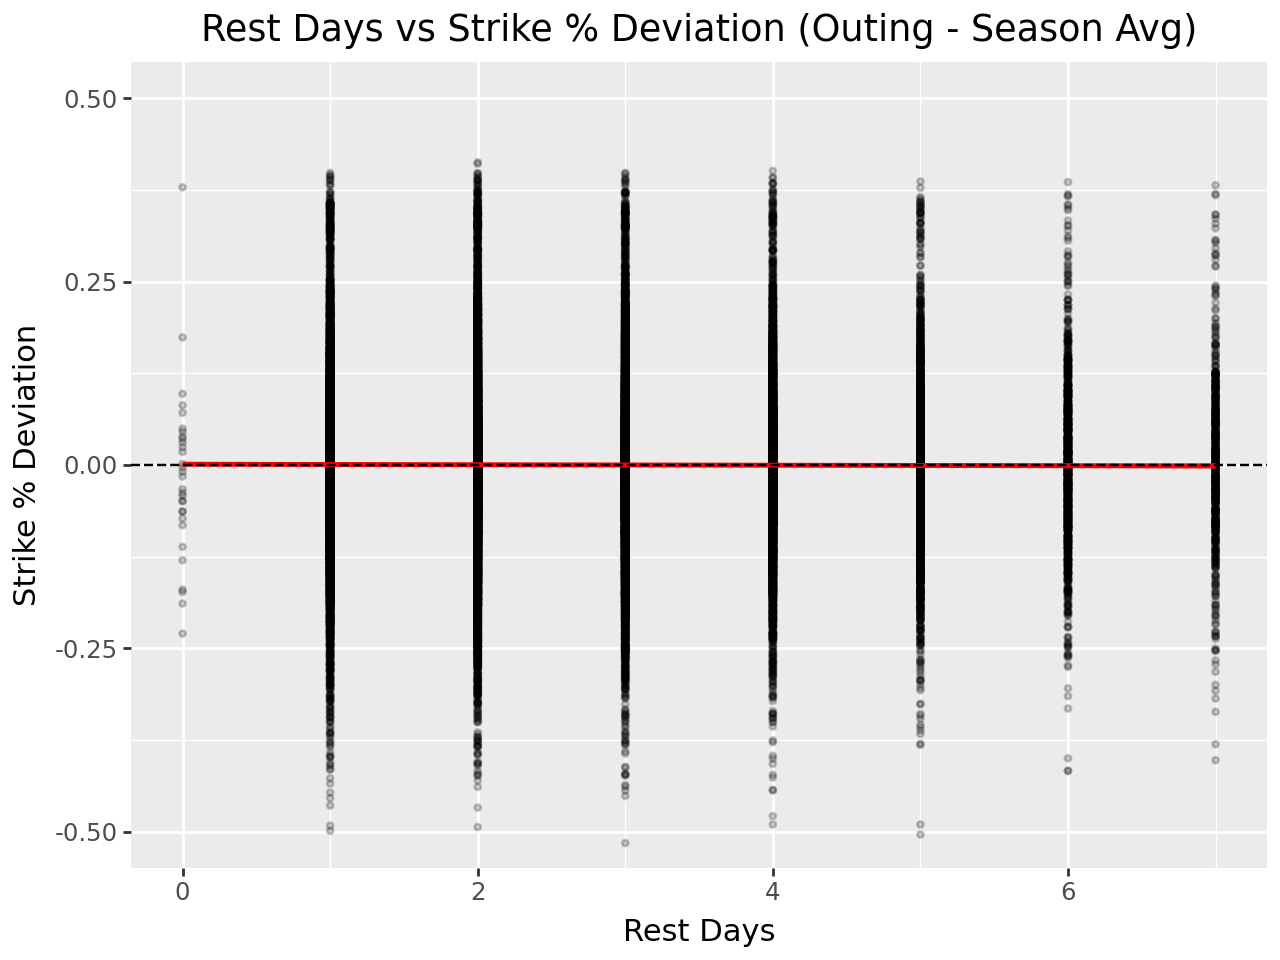

In [44]:
plot_df = (
    complete_outing_table
    .select(["rest_days", "strike_pct_deviation"])
    .drop_nulls(["rest_days", "strike_pct_deviation"])
    .to_pandas()
)

(
    ggplot(plot_df, aes(x="rest_days", y="strike_pct_deviation")) +
    geom_point(alpha=0.2, size=0.8) +
    geom_smooth(method="lm", se=True, color="red") +
    geom_hline(yintercept=0, linetype="dashed") +
    coord_cartesian(ylim=(-.5, .5)) +
    labs(
        title="Rest Days vs Strike % Deviation (Outing - Season Avg)",
        x="Rest Days",
        y="Strike % Deviation"
    )
)

In [45]:
features = ["rest_days", "prev_pitch_count", "pitches_last_3d", "inning_entered", "score_diff"]
target = "strike_pct_deviation"

d = (
    complete_outing_table
    .select(features + [target])
    .drop_nulls(features + [target])
    .to_pandas()
)

X = d[features].values
y = d[target].values

model = LinearRegression()
model.fit(X, y)

pred = model.predict(X)
r2 = r2_score(y, pred)

coef_table = (
    pd.DataFrame({"feature": features, "slope": model.coef_})
    .sort_values("slope", ascending=False)
)

print(f"Multivariable model: {target} ~ " + " + ".join(features))
print(f"N={len(y)}  R²={r2:.4f}  intercept={model.intercept_:.6f}")
display(coef_table.reset_index(drop=True))

Multivariable model: strike_pct_deviation ~ rest_days + prev_pitch_count + pitches_last_3d + inning_entered + score_diff
N=24391  R²=0.0006  intercept=-0.000523


,feature,slope
0,score_diff,0.000887
1,inning_entered,0.000292
2,prev_pitch_count,0.000074
3,pitches_last_3d,-0.000041
4,rest_days,-0.001364


In [46]:
(first_pitch_outings := (
    relievers
    .filter(pl.col("pitch_num") == 1)
    .with_columns(
        (pl.col("strike/ball") == "s").cast(pl.Int8).alias("is_fp_strike")
    )
    .group_by(["pitcher_id", "game_id"])
    .agg([
        pl.len().alias("first_pitches"),
        pl.sum("is_fp_strike").alias("first_pitch_strikes")
    ])
    .with_columns(
        (pl.col("first_pitch_strikes") / pl.col("first_pitches"))
        .alias("first_pitch_strike_pct")
    )
))

pitcher_id,game_id,first_pitches,first_pitch_strikes,first_pitch_strike_pct
i64,i64,u32,i64,f64
445926,718743,3,3,1.0
656794,632615,5,2,0.4
657571,662685,4,2,0.5
669424,717480,8,7,0.875
669674,746278,3,1,0.333333
…,…,…,…,…
641793,633471,3,2,0.666667
687330,716524,7,5,0.714286
641394,632511,3,3,1.0


In [47]:
complete_outing_table = complete_outing_table.join(
    first_pitch_outings.select(["pitcher_id", "game_id", "first_pitch_strike_pct"]),
    on=["pitcher_id", "game_id"],
    how="left"
)

In [48]:
(complete_outing_table := (
    complete_outing_table
    .with_columns(
        pl.col("first_pitch_strike_pct")
        .mean()
        .over(["pitcher_id", "year"])
        .alias("season_avg_fp_strike_pct")
    )
    .with_columns(
        (pl.col("first_pitch_strike_pct") - pl.col("season_avg_fp_strike_pct"))
        .alias("fp_strike_pct_deviation")
    )
))

pitcher_id,game_id,date,year,pitcher_name,fb_count,mean_fb_velocity,max_fb_velocity,mean_fb_spin_rate,mean_h_movement,mean_v_movement,inning_entered,pitcher_hand,score_diff,rest_days,pitch_count,prev_pitch_count,season_avg_fb_velo,season_avg_fb_spin,velo_deviation,spin_deviation,pitches_last_1d,pitches_last_2d,pitches_last_3d,pitches_last_4d,pitches_last_5d,pitches_last_6d,season_avg_h_movement,season_avg_v_movement,h_movement_deviation,v_movement_deviation,prev_pitch_bin,current_pitch_bin,abs_velo_deviation,strike_pct,season_avg_strike_pct,strike_pct_deviation,first_pitch_strike_pct,season_avg_fp_strike_pct,fp_strike_pct_deviation
i64,i64,datetime[ns],i32,str,u32,f64,f64,f64,f64,f64,i64,str,i64,i64,u32,u32,f64,f64,f64,f64,u32,u32,u32,u32,u32,u32,f64,f64,f64,f64,str,str,f64,f64,f64,f64,f64,f64,f64
433589,634628,2021-04-06 00:00:00,2021,"""Yusmeiro Petit""",12,85.091667,87.3,2077.833333,-0.3275,1.535833,8,"""R""",-3,2,16,26,86.615973,2137.198876,-1.524306,-59.365543,null,null,null,null,null,null,-0.313921,1.491772,-0.013579,0.044061,"""21-30""","""11-20""",1.524306,0.5625,0.675712,-0.113212,0.25,0.633114,-0.383114
433589,634567,2021-04-07 00:00:00,2021,"""Yusmeiro Petit""",8,84.775,87.4,2039.0,-0.325,1.4825,10,"""R""",0,1,10,16,86.615973,2137.198876,-1.840973,-98.198876,16,16,16,16,16,16,-0.313921,1.491772,-0.011079,-0.009272,"""11-20""","""≤10""",1.840973,0.6,0.675712,-0.075712,0.333333,0.633114,-0.299781
433589,634537,2021-04-09 00:00:00,2021,"""Yusmeiro Petit""",8,86.1375,89.2,2141.5,-0.31375,1.555,7,"""R""",0,2,8,10,86.615973,2137.198876,-0.478473,4.301124,null,10,26,26,26,26,-0.313921,1.491772,0.000171,0.063228,"""≤10""","""≤10""",0.478473,0.875,0.675712,0.199288,1.0,0.633114,0.366886
433589,632231,2021-04-12 00:00:00,2021,"""Yusmeiro Petit""",7,86.357143,87.7,2242.0,-0.18,1.548571,6,"""R""",3,3,10,8,86.615973,2137.198876,-0.25883,104.801124,null,null,8,8,18,34,-0.313921,1.491772,0.133921,0.056799,"""≤10""","""≤10""",0.25883,0.6,0.675712,-0.075712,0.5,0.633114,-0.133114
433589,632206,2021-04-13 00:00:00,2021,"""Yusmeiro Petit""",4,86.7,88.3,2058.5,-0.0875,1.3625,7,"""R""",0,1,6,10,86.615973,2137.198876,0.084027,-78.698876,10,10,10,18,18,28,-0.313921,1.491772,0.226421,-0.129272,"""≤10""","""≤10""",0.084027,0.666667,0.675712,-0.009045,0.0,0.633114,-0.633114
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
702352,746985,2024-09-19 00:00:00,2024,"""Spencer Bivens""",32,94.1,97.5,2093.96875,-0.650938,0.590938,8,"""R""",-1,4,37,13,94.048879,1941.835625,0.051121,152.133125,null,null,null,13,13,13,-1.036227,0.51891,0.38529,0.072027,"""11-20""","""31+""",0.051121,0.621622,0.655255,-0.033633,0.5,0.637626,-0.137626
702352,746255,2024-09-21 00:00:00,2024,"""Spencer Bivens""",18,95.127778,97.2,2105.0,-0.842222,0.501667,7,"""R""",9,2,28,37,94.048879,1941.835625,1.078899,163.164375,null,37,37,37,37,50,-1.036227,0.51891,0.194005,-0.017243,"""31+""","""21-30""",1.078899,0.678571,0.655255,0.023316,0.75,0.637626,0.112374
702352,747150,2024-09-23 00:00:00,2024,"""Spencer Bivens""",14,94.907143,97.1,2092.5,-0.977857,0.445714,6,"""R""",3,2,21,28,94.048879,1941.835625,0.858264,150.664375,null,28,28,65,65,65,-1.036227,0.51891,0.05837,-0.073196,"""21-30""","""21-30""",0.858264,0.619048,0.655255,-0.036207,0.5,0.637626,-0.137626


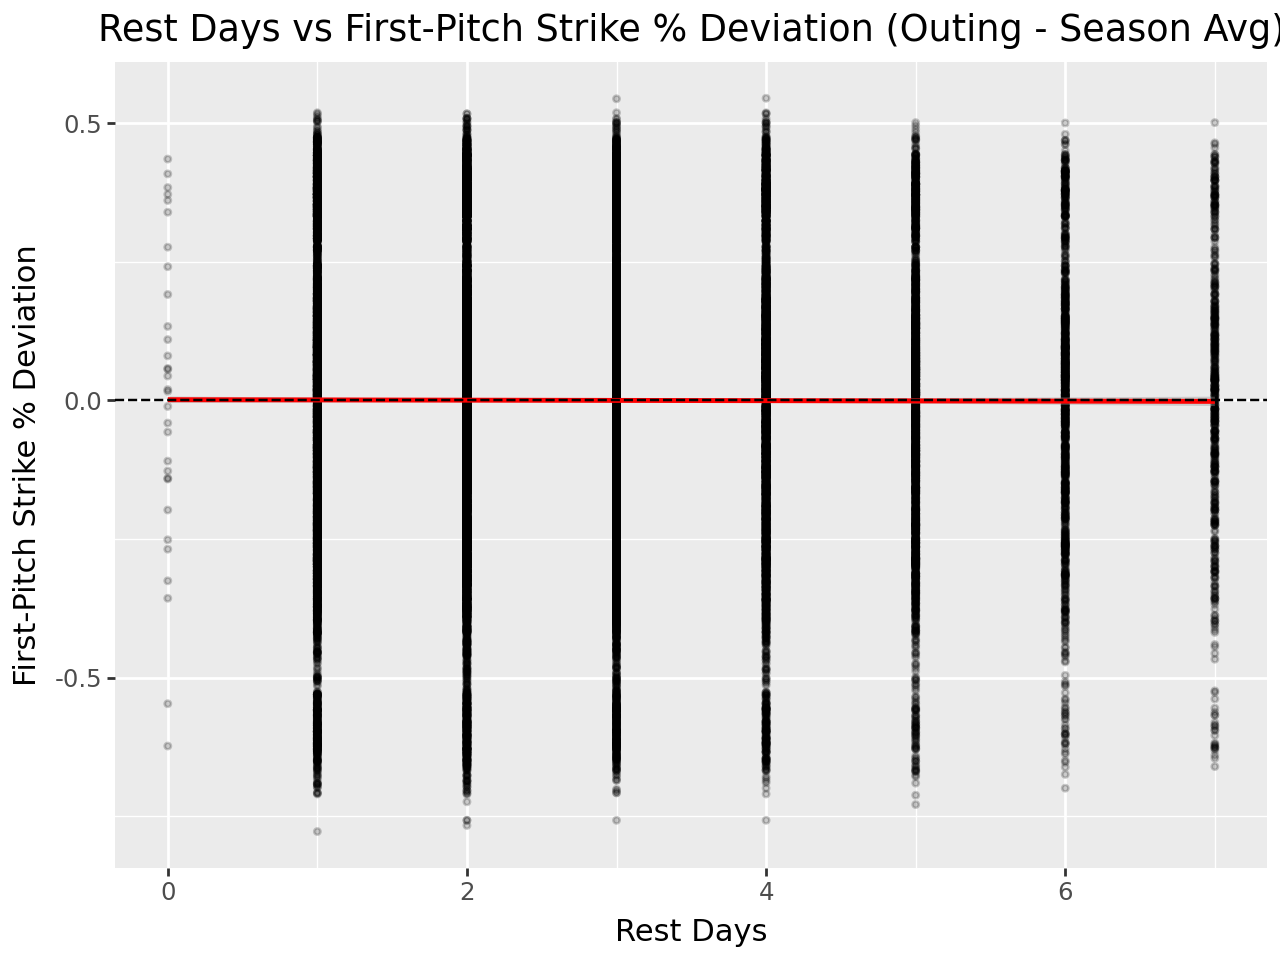

In [49]:
plot_df = (
    complete_outing_table
    .select(["rest_days", "fp_strike_pct_deviation"])
    .drop_nulls(["rest_days", "fp_strike_pct_deviation"])
    .to_pandas()
)

(
    ggplot(plot_df, aes(x="rest_days", y="fp_strike_pct_deviation")) +
    geom_point(alpha=0.2, size=0.8) +
    geom_smooth(method="lm", se=True, color="red") +
    geom_hline(yintercept=0, linetype="dashed") +
    labs(
        title="Rest Days vs First-Pitch Strike % Deviation (Outing - Season Avg)",
        x="Rest Days",
        y="First-Pitch Strike % Deviation"
    ) 
)

In [50]:
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

features = ["rest_days", "prev_pitch_count", "pitches_last_3d", "inning_entered", "score_diff"]
target = "fp_strike_pct_deviation"

d = (
    complete_outing_table
    .select(features + [target])
    .drop_nulls(features + [target])
    .to_pandas()
)

X = d[features].values
y = d[target].values

model = LinearRegression()
model.fit(X, y)

pred = model.predict(X)
r2 = r2_score(y, pred)

coef_table = (
    pd.DataFrame({"feature": features, "slope": model.coef_})
    .sort_values("slope", ascending=False)
)

print(f"Multivariable model: {target} ~ " + " + ".join(features))
print(f"N={len(y)}  R²={r2:.4f}  intercept={model.intercept_:.6f}")
display(coef_table.reset_index(drop=True))

Multivariable model: fp_strike_pct_deviation ~ rest_days + prev_pitch_count + pitches_last_3d + inning_entered + score_diff
N=24389  R²=0.0002  intercept=0.008944


,feature,slope
0,pitches_last_3d,0.000319
1,score_diff,0.000171
2,prev_pitch_count,-0.000095
3,inning_entered,-0.001247
4,rest_days,-0.002008


In [51]:
complete_outing_table.write_parquet('data/complete_outing_table.parquet')